# Do Transformers Actually Help Intrusion Detection?

Multi-seed reproduction notebook for the paper *Do Transformers Actually
Help Intrusion Detection? A Temporal Sequence Evaluation on CIC-IDS2017*.

Runs every experiment in the paper with three random seeds ({2, 42, 123})
and writes a per-seed CSV plus a mean ± std summary CSV next to each figure.
Outputs are written to `figures_v5/` (set `EEE402_FIG_DIR` to override).

Designed for a single **Restart & Run All** pass: about 5–8 hours on an A100.
Every experiment checkpoints its CSVs as it goes, so the run is recoverable
from a disconnect.


In [1]:
# imports
import os, gc, time, math, random, json
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split as sk_split
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

print(f'TF: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')

TF: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# constants
SEEDS = [2, 42, 123]                 # 3 seeds
SEEDS_TSWEEP = SEEDS                 # set to [42] if the T-sweep cell below is too slow

DATA_PATH = os.environ.get(
    'EEE402_DATA_PATH',
    '/content/drive/MyDrive/EEE402_Project/CIC-IDS2017/Network-Flows/CICIDS_Flow.parquet',
)
FIG_DIR = os.environ.get(
    'EEE402_FIG_DIR',
    '/content/drive/MyDrive/EEE402_Project/figures_v5',
)
os.makedirs(FIG_DIR, exist_ok=True)

LABEL_COL_DEFAULT = 'attack_label'

# Windowing
TIMESTEPS = 20
MAX_PER_GROUP = 50
MIN_GROUP_LEN = 2

# Architecture
EMBED_DIM, NUM_HEADS, FF_DIM, NUM_BLOCKS = 128, 4, 256, 2
EMBED_DIM_S, NUM_HEADS_S, FF_DIM_S, NUM_BLOCKS_S = 64, 2, 128, 1

# Training
EPOCHS = 30
ES_PATIENCE = 6
LR_REDUCE_FACTOR, LR_REDUCE_PATIENCE, MIN_LR = 0.5, 2, 1e-6
BATCH_SEQ = 1024
BATCH_TRANS = 256
LR_LSTM, LR_GRU, LR_CNN1D, LR_TRANS = 1e-3, 5e-4, 1e-3, 5e-4
TRAIN_RATIO = 0.8

# Subsampling caps
SVM_CAP = 50_000
RF_CAP = 50_000
STATIC15_CAP = 25_000

# T-sweep
T_SWEEP = (5, 10, 20)
LR_SWEEP_REC = (1e-3, 5e-4)
LR_SWEEP_TRANS = (1e-3, 5e-4, 1e-4)

# Latency benchmark (no-seed: forward-pass timing only)
LAT_T_VALS = (5, 10, 20, 30, 50)
LAT_BATCH = 128
LAT_REPEATS = 20  # bumped from 5 so std is meaningful

print(f'SEEDS: {SEEDS}')
print(f'FIG_DIR: {FIG_DIR}')

SEEDS: [2, 42, 123]
FIG_DIR: /content/drive/MyDrive/EEE402_Project/figures_v5


In [3]:
# plotting + determinism setup
plt.rcParams.update({
    'font.size':          14,
    'axes.titlesize':     16,
    'axes.labelsize':     14,
    'xtick.labelsize':    12,
    'ytick.labelsize':    12,
    'legend.fontsize':    12,
    'figure.titlesize':   18,
    'figure.dpi':         100,
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'pdf.fonttype':       42,   # editable text in PDF
    'ps.fonttype':        42,
})
sns.set_style('whitegrid')

def set_global_seed(seed: int):
    """Initialise every RNG TF/Keras/sklearn touch."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def save_fig(fig, name, fig_dir=FIG_DIR):
    """Save figure as both PNG (preview) and PDF (paper, text-selectable)."""
    os.makedirs(fig_dir, exist_ok=True)
    fig.savefig(os.path.join(fig_dir, f'{name}.png'), dpi=300, bbox_inches='tight')
    fig.savefig(os.path.join(fig_dir, f'{name}.pdf'),               bbox_inches='tight')
def free_memory():
    """Call between models to keep VRAM in check."""
    tf.keras.backend.clear_session()
    gc.collect()

---
## Load CIC-IDS2017

Deterministic. Runs once.

In [4]:
# Load CIC-IDS2017 (on Colab this mounts Drive; elsewhere set EEE402_DATA_PATH)
import glob
import shutil

try:
    from google.colab import drive   # only available on Colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # clear a stale, non-mounted mount dir left over from a crashed session
    if os.path.isdir('/content/drive') and not os.path.ismount('/content/drive'):
        print(f'Clearing stale mount dir. Contained: {os.listdir("/content/drive")}')
        shutil.rmtree('/content/drive')
    drive.mount('/content/drive')

# ensure the output dir exists on the real (mounted) filesystem —
# pandas to_csv does not create parent directories
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(DATA_PATH):
    search = glob.glob(os.path.join(os.path.dirname(DATA_PATH), '*.parquet'))
    if search:
        DATA_PATH = search[0]
    else:
        raise FileNotFoundError(
            f'Cannot find the data file at {DATA_PATH}. '
            'Run EEE402_Data_Download.ipynb first, or set EEE402_DATA_PATH.')

df = pd.read_parquet(DATA_PATH)
df.columns = df.columns.str.strip()
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')


Clearing stale mount dir. Contained: ['MyDrive']
Mounted at /content/drive
Loaded: 2,827,677 rows x 84 columns
Memory: 2840 MB


---
## Preprocessing

Replace ±∞, drop NaN, encode label, pick feature columns.

In [5]:
# detect column variants (CIC-IDS2017 has different column-name styles per source)
TUPLE_VARIANTS = [
    ['Source IP', 'Destination IP', 'Source Port', 'Destination Port', 'Protocol'],
    ['source_ip', 'destination_ip', 'source_port', 'destination_port', 'protocol'],
    ['Src IP',    'Dst IP',         'Src Port',    'Dst Port',         'Protocol'],
]
TUPLE_COLS = next((v for v in TUPLE_VARIANTS if all(c in df.columns for c in v)), None)
if TUPLE_COLS is None:
    raise RuntimeError('Could not find 5-tuple columns')
TIME_COL = next(c for c in df.columns if 'time' in c.lower())
LABEL_COL = LABEL_COL_DEFAULT if LABEL_COL_DEFAULT in df.columns else 'Label'
print(f'5-tuple: {TUPLE_COLS}')
print(f'time col: {TIME_COL}   label col: {LABEL_COL}')

5-tuple: ['source_ip', 'destination_ip', 'source_port', 'destination_port', 'protocol']
time col: Timestamp   label col: attack_label


In [6]:
# clean + encode
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
print(f'After ±inf/NaN drop: {df.shape[0]:,} rows')

le = LabelEncoder()
df['label_enc'] = le.fit_transform(df[LABEL_COL])
NUM_CLASSES_15 = len(le.classes_)
CLASS_NAMES_15 = list(le.classes_)
for i, name in enumerate(CLASS_NAMES_15):
    n = (df['label_enc'] == i).sum()
    print(f'  {i:2d}. {name:30s} {n:>10,} ({100*n/len(df):.2f}%)')

df = df.sort_values(TIME_COL).reset_index(drop=True)

After ±inf/NaN drop: 2,827,677 rows
   0. BENIGN                          2,271,122 (80.32%)
   1. Bot                                 1,956 (0.07%)
   2. DDoS                              128,025 (4.53%)
   3. DoS GoldenEye                      10,293 (0.36%)
   4. DoS Hulk                          230,123 (8.14%)
   5. DoS Slowhttptest                    5,499 (0.19%)
   6. DoS slowloris                       5,796 (0.20%)
   7. FTP-Patator                         7,935 (0.28%)
   8. Heartbleed                             11 (0.00%)
   9. Infiltration                           36 (0.00%)
  10. PortScan                          158,804 (5.62%)
  11. SSH-Patator                         5,897 (0.21%)
  12. Web Attack – Brute Force            1,507 (0.05%)
  13. Web Attack – Sql Injection             21 (0.00%)
  14. Web Attack – XSS                      652 (0.02%)


In [7]:
# feature columns (76 numeric)
DROP = set([LABEL_COL, 'Label', 'label_enc', 'flow_id', 'Flow ID', 'FlowID', TIME_COL] + TUPLE_COLS)
feat_cols = [c for c in df.columns if c not in DROP and pd.api.types.is_numeric_dtype(df[c])]
F = len(feat_cols)
print(f'feature columns: F = {F}')
print(f'first 8: {feat_cols[:8]}')

feature columns: F = 76
first 8: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean']


---
## Sliding $T=20$ windows (both padding schemes)

Two builds, both deterministic:
- `X_repeat`: repeat-last padding → primary protocol for Tables III, V, latency, T-sweep
- `X_zp`: zero-pad + per-position mask → padding ablation, non-padded subset, realistic eval

Class subset reduces 15 → 13 (Heartbleed, DoS Slowhttptest dropped: <2 windows each; DoS slowloris is kept).

In [8]:
# windowing function
def build_windows_inline(df_in, repeat_last=True, T=TIMESTEPS,
                          max_per_group=MAX_PER_GROUP, min_len=MIN_GROUP_LEN,
                          tuple_cols=None, feature_cols=None):
    tuple_cols = tuple_cols or TUPLE_COLS
    feature_cols = feature_cols or feat_cols
    df_loc = df_in.reset_index(drop=True)
    feat = df_loc[feature_cols].values.astype(np.float32)
    lab  = df_loc['label_enc'].values
    groups = df_loc.groupby(tuple_cols, sort=False)
    Fdim = len(feature_cols)

    windows, labels, masks = [], [], []
    n_pad, n_drop = 0, 0
    for key, idx_obj in groups.groups.items():
        idx = idx_obj.values
        if len(idx) < min_len:
            n_drop += 1
            continue
        if len(idx) < T:
            real = feat[idx]
            pad_len = T - len(idx)
            if repeat_last:
                padded = np.concatenate([idx, np.full(pad_len, idx[-1])])
                windows.append(feat[padded])
                masks.append(np.ones(T, dtype=np.float32))
            else:
                feats_pad = np.vstack([real, np.zeros((pad_len, real.shape[1]), np.float32)])
                windows.append(feats_pad)
                masks.append(np.concatenate([np.ones(len(idx)), np.zeros(pad_len)]).astype(np.float32))
            labels.append(lab[idx[-1]])
            n_pad += 1
        else:
            n_w = len(idx) - T + 1
            starts = (np.linspace(0, n_w - 1, max_per_group, dtype=int)
                      if n_w > max_per_group else np.arange(n_w))
            for s in starts:
                wi = idx[s:s+T]
                windows.append(feat[wi])
                labels.append(lab[wi[-1]])
                masks.append(np.ones(T, dtype=np.float32))

    X = np.stack(windows).astype(np.float32) if windows else np.empty((0, T, Fdim), np.float32)
    y = np.array(labels)
    M = np.stack(masks).astype(np.float32) if masks else np.empty((0, T), np.float32)
    info = {'n_groups': groups.ngroups, 'n_padded': n_pad, 'n_dropped': n_drop}
    return X, y, M, info

In [9]:
# build both padding schemes
t0 = time.time()
X_repeat, y_repeat, M_repeat, info_r = build_windows_inline(df, repeat_last=True)
print(f'Repeat-last: X={X_repeat.shape}  ({time.time()-t0:.1f}s)')
print(f'  groups={info_r["n_groups"]:,}  padded={info_r["n_padded"]:,}  dropped={info_r["n_dropped"]:,}')

t0 = time.time()
X_zp, y_zp, M_zp, info_z = build_windows_inline(df, repeat_last=False)
print(f'Zero-pad+mask: X={X_zp.shape}  ({time.time()-t0:.1f}s)')

Repeat-last: X=(630265, 20, 76)  (68.6s)
  groups=1,456,266  padded=460,729  dropped=983,768
Zero-pad+mask: X=(630265, 20, 76)  (66.2s)


In [10]:
# 13-class subset (drops Heartbleed and DoS Slowhttptest, the only classes with <2 windows)
counts = np.bincount(y_repeat, minlength=NUM_CLASSES_15)
viable = sorted(i for i in range(NUM_CLASSES_15) if counts[i] >= 2)
remap = {old: new for new, old in enumerate(viable)}
keep_r = np.isin(y_repeat, viable)
keep_z = np.isin(y_zp,     viable)
X_repeat, y_repeat, M_repeat = X_repeat[keep_r], np.array([remap[v] for v in y_repeat[keep_r]]), M_repeat[keep_r]
X_zp,     y_zp,     M_zp     = X_zp[keep_z],     np.array([remap[v] for v in y_zp[keep_z]]),     M_zp[keep_z]
NUM_CLASSES = len(viable)
CLASS_NAMES = [CLASS_NAMES_15[i] for i in viable]
dropped = [CLASS_NAMES_15[i] for i in range(NUM_CLASSES_15) if i not in viable]
print(f'{NUM_CLASSES}-class subset: {len(X_repeat):,} repeat-last / {len(X_zp):,} zero-pad windows')
print(f'dropped (<2 windows): {dropped}')
print(f'classes: {CLASS_NAMES}')
assert NUM_CLASSES == 13, f'expected 13 viable classes on CIC-IDS2017, got {NUM_CLASSES}'

# Padded fraction of the FINAL window set. A window is padded iff its
# conversation is shorter than T; that is identical under both schemes, and
# recoverable from the zero-pad masks.
n_padded_final = int((M_zp.sum(axis=1) < TIMESTEPS).sum())
pd.DataFrame([{
    'scheme': 'repeat-last', 'n_windows': len(X_repeat),
    'n_groups': info_r['n_groups'], 'n_padded': n_padded_final,
    'n_dropped': info_r['n_dropped'],
    'padded_fraction': n_padded_final / len(X_repeat),
}, {
    'scheme': 'zero-pad+mask', 'n_windows': len(X_zp),
    'n_groups': info_z['n_groups'], 'n_padded': n_padded_final,
    'n_dropped': info_z['n_dropped'],
    'padded_fraction': n_padded_final / len(X_zp),
}]).to_csv(os.path.join(FIG_DIR, 'windowing_info.csv'), index=False)

# Window-level class distribution (documents the class shares quoted in the paper)
win_counts = np.bincount(y_repeat, minlength=NUM_CLASSES)
dist = pd.DataFrame({'class': CLASS_NAMES, 'n_windows': win_counts,
                     'pct_windows': np.round(100 * win_counts / len(y_repeat), 3)})
dist.to_csv(os.path.join(FIG_DIR, 'window_class_distribution.csv'), index=False)
print(dist.to_string(index=False))


13-class subset: 630,264 repeat-last / 630,264 zero-pad windows
dropped (<2 windows): ['DoS Slowhttptest', 'Heartbleed']
classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS slowloris', 'FTP-Patator', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack – Brute Force', 'Web Attack – Sql Injection', 'Web Attack – XSS']
                     class  n_windows  pct_windows
                    BENIGN     557943       88.525
                       Bot         27        0.004
                      DDoS      55404        8.791
             DoS GoldenEye       3438        0.545
                  DoS Hulk       3589        0.569
             DoS slowloris       1498        0.238
               FTP-Patator       3874        0.615
              Infiltration          5        0.001
                  PortScan        454        0.072
               SSH-Patator       2889        0.458
  Web Attack – Brute Force        839        0.133
Web Attack – Sql Injection         16        0.003

---
## Per-seed split, scale, image-encode helpers

Splits and scalers are seed-dependent (stratified split needs `random_state`; scaler is fit on train indices).

In [11]:
# stratified random split (per seed)
def stratified_split(X, y, M, seed, test_size=1 - TRAIN_RATIO):
    train_idx, test_idx = sk_split(
        np.arange(len(X)), test_size=test_size, random_state=seed, stratify=y,
    )
    Xtr, Xte = X[train_idx], X[test_idx]
    ytr, yte = y[train_idx], y[test_idx]
    Mtr = M[train_idx] if M is not None else None
    Mte = M[test_idx]  if M is not None else None
    # Drop any class that fell out of either side (rare with stratify but possible)
    present = sorted(set(np.unique(ytr)) & set(np.unique(yte)))
    rmap    = {old: new for new, old in enumerate(present)}
    keep_tr = np.isin(ytr, present)
    keep_te = np.isin(yte, present)
    Xtr, ytr = Xtr[keep_tr], np.array([rmap[v] for v in ytr[keep_tr]])
    Xte, yte = Xte[keep_te], np.array([rmap[v] for v in yte[keep_te]])
    if M is not None:
        Mtr, Mte = Mtr[keep_tr], Mte[keep_te]
    return (Xtr, ytr, Mtr), (Xte, yte, Mte), present

In [12]:
# z-score + image encoding
def fit_zscore(X_train, mask=None):
    n, T, Fd = X_train.shape
    if mask is not None:
        real = mask.reshape(-1).astype(bool)
        sc = StandardScaler().fit(X_train.reshape(-1, Fd)[real])
    else:
        sc = StandardScaler().fit(X_train.reshape(-1, Fd))
    return sc

def apply_zscore(sc, X, mask=None):
    n, T, Fd = X.shape
    flat = sc.transform(X.reshape(-1, Fd)).astype(np.float32)
    if mask is not None:
        flat = flat * mask.reshape(-1, 1)
    return flat.reshape(n, T, Fd)

def fit_image_enc(X_train, mask=None):
    n, T, Fd = X_train.shape
    side = int(math.ceil(math.sqrt(Fd)))
    n_pad = side * side - Fd
    if mask is not None:
        real = mask.reshape(-1).astype(bool)
        mm = MinMaxScaler().fit(X_train.reshape(-1, Fd)[real])
    else:
        mm = MinMaxScaler().fit(X_train.reshape(-1, Fd))
    return mm, side, n_pad

def encode_imgs(mm, X, side, n_pad, mask=None):
    n, T, Fd = X.shape
    flat = mm.transform(X.reshape(-1, Fd)).astype(np.float32)
    if mask is not None:
        flat = flat * mask.reshape(-1, 1)
    flat = np.pad(flat, ((0, 0), (0, n_pad)), mode='constant')
    return flat.reshape(n, T, side, side, 1)

def class_weight_dict(y, num_classes):
    counts = np.bincount(y, minlength=num_classes)
    return {i: float(len(y) / (num_classes * c)) if c > 0 else 0.0
            for i, c in enumerate(counts)}

In [13]:
# cap-per-class subsampler (used by SVM/RF)
def cap_per_class(y, cap, seed):
    rng = np.random.RandomState(seed)
    keep = []
    for c in np.unique(y):
        ci = np.where(y == c)[0]
        if len(ci) > cap:
            ci = rng.choice(ci, cap, replace=False)
        keep.extend(ci)
    return np.array(sorted(keep))

---
## Model builders

Three Transformer fixes live in `MaskedTransformerBlock` and the wiring of `build_masked_transformer`.

In [14]:
# Transformer building blocks
class PositionalEncoding(layers.Layer):
    def __init__(self, max_len, embed_dim, **kw):
        super().__init__(**kw)
        pos = np.arange(max_len)[:, None]
        i   = np.arange(embed_dim)[None, :]
        rates  = 1 / np.power(10000, (2 * (i // 2)) / np.float32(embed_dim))
        angles = pos * rates
        pe = np.zeros((max_len, embed_dim), dtype=np.float32)
        pe[:, 0::2] = np.sin(angles[:, 0::2])
        pe[:, 1::2] = np.cos(angles[:, 1::2])
        self.pe = tf.constant(pe[None, :, :])
    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

class CLSToken(layers.Layer):
    def __init__(self, embed_dim, **kw):
        super().__init__(**kw)
        self.embed_dim = embed_dim
    def build(self, input_shape):
        self.cls = self.add_weight(
            name='cls_token', shape=(1, 1, self.embed_dim),
            initializer=tf.keras.initializers.TruncatedNormal(stddev=0.02), trainable=True,
        )
    def call(self, x):
        b = tf.shape(x)[0]
        return tf.concat([tf.broadcast_to(self.cls, (b, 1, self.embed_dim)), x], axis=1)

class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kw):
        super().__init__(**kw)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
    def call(self, x, training=False):
        attn = self.drop1(self.mha(x, x), training=training)
        x    = self.ln1(x + attn)
        ffn  = self.drop2(self.ffn(x), training=training)
        return self.ln2(x + ffn)

class MaskedTransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kw):
        super().__init__(**kw)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn = models.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim),
        ])
        self.ln1 = layers.LayerNormalization(epsilon=1e-6)
        self.ln2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
    def call(self, x, pad_mask=None, training=False):
        # attention_mask blocks padded keys from receiving attention weight
        attn_mask = tf.cast(pad_mask, tf.bool)[:, None, :] if pad_mask is not None else None
        attn = self.drop1(self.mha(x, x, attention_mask=attn_mask), training=training)
        x    = self.ln1(x + attn)
        ffn  = self.drop2(self.ffn(x), training=training)
        return self.ln2(x + ffn)

In [15]:
# static + recurrent + 1D-CNN builders
def build_svm(seed):
    return LinearSVC(C=1.0, class_weight='balanced', max_iter=2000, random_state=seed)

def build_rf(seed, n_estimators=100, max_depth=20):
    return RandomForestClassifier(
        n_estimators=n_estimators, max_depth=max_depth, n_jobs=-1,
        class_weight='balanced', random_state=seed,
    )

def build_mlp(num_features, num_classes, lr=1e-3):
    m = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(64,  activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_image_cnn(side, num_classes, lr=1e-3):
    m = models.Sequential([
        layers.Input(shape=(side, side, 1)),
        layers.Conv2D(32, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(128, activation='relu'), layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ])
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_lstm(T, Fd, num_classes, lr=LR_LSTM, mask=False):
    body = [layers.Input(shape=(T, Fd))]
    if mask:
        body.append(layers.Masking(mask_value=0.0))
    body += [
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ]
    m = models.Sequential(body)
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_gru(T, Fd, num_classes, lr=LR_GRU, mask=False):
    body = [layers.Input(shape=(T, Fd))]
    if mask:
        body.append(layers.Masking(mask_value=0.0))
    body += [
        layers.GRU(64, return_sequences=True),
        layers.GRU(32),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ]
    m = models.Sequential(body)
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_cnn1d(T, Fd, num_classes, lr=LR_CNN1D, mask=False):
    # NOTE: Conv1D cannot consume a Keras mask (it would be silently
    # discarded), so callers should pass mask=False and rely on the zeroed
    # inputs themselves; the flag is kept for API symmetry.
    body = [layers.Input(shape=(T, Fd))]
    if mask:
        body.append(layers.Masking(mask_value=0.0))
    body += [
        layers.Conv1D(64,  3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ]
    m = models.Sequential(body)
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m


In [16]:
# Transformer + Transformer-small builders (unmasked + masked variants)
def cnn_extractor(side, embed_dim):
    return models.Sequential([
        layers.Input(shape=(side, side, 1)),
        layers.Conv2D(32, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(embed_dim, activation='relu'),
    ])

def build_transformer(T, side, num_classes, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                      ff_dim=FF_DIM, num_blocks=NUM_BLOCKS, lr=LR_TRANS):
    cnn = cnn_extractor(side, embed_dim)
    inp = layers.Input(shape=(T, side, side, 1))
    x = layers.TimeDistributed(cnn)(inp)
    x = PositionalEncoding(T, embed_dim)(x)
    x = CLSToken(embed_dim)(x)
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    cls_out = layers.Lambda(lambda t: t[:, 0, :])(x)
    cls_out = layers.Dropout(0.3)(cls_out)
    out = layers.Dense(num_classes, activation='softmax')(cls_out)
    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_transformer_small(T, side, num_classes, lr=LR_TRANS):
    return build_transformer(T, side, num_classes,
                              embed_dim=EMBED_DIM_S, num_heads=NUM_HEADS_S,
                              ff_dim=FF_DIM_S, num_blocks=NUM_BLOCKS_S, lr=lr)

def build_masked_transformer(T, side, num_classes, embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
                              ff_dim=FF_DIM, num_blocks=NUM_BLOCKS, lr=LR_TRANS):
    cnn = cnn_extractor(side, embed_dim)
    inp_x = layers.Input(shape=(T, side, side, 1), name='img_in')
    inp_m = layers.Input(shape=(T,),                name='mask_in')
    x = layers.TimeDistributed(cnn)(inp_x)
    x = PositionalEncoding(T, embed_dim)(x)
    # post-PE re-mask
    x = layers.Lambda(lambda a: a[0] * tf.expand_dims(a[1], -1))([x, inp_m])
    # [CLS]
    x = CLSToken(embed_dim)(x)
    full_mask = layers.Lambda(
        lambda m: tf.concat([tf.ones((tf.shape(m)[0], 1)), m], axis=1)
    )(inp_m)
    for _ in range(num_blocks):
        x = MaskedTransformerBlock(embed_dim, num_heads, ff_dim)(x, pad_mask=full_mask)
    cls_out = layers.Lambda(lambda t: t[:, 0, :])(x)
    cls_out = layers.Dropout(0.3)(cls_out)
    out = layers.Dense(num_classes, activation='softmax')(cls_out)
    m = models.Model([inp_x, inp_m], out)
    m.compile(optimizer=optimizers.Adam(lr, clipnorm=1.0),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def build_masked_transformer_small(T, side, num_classes, lr=LR_TRANS):
    return build_masked_transformer(T, side, num_classes,
                                     embed_dim=EMBED_DIM_S, num_heads=NUM_HEADS_S,
                                     ff_dim=FF_DIM_S, num_blocks=NUM_BLOCKS_S, lr=lr)

In [17]:
# parameter counts for every architecture (reported in Table II)
side = int(math.ceil(math.sqrt(F)))
param_rows = []
for name, build in [
    ('MLP',               lambda: build_mlp(F, NUM_CLASSES)),
    ('Image-CNN',         lambda: build_image_cnn(side, NUM_CLASSES)),
    ('LSTM',              lambda: build_lstm(TIMESTEPS, F, NUM_CLASSES)),
    ('GRU',               lambda: build_gru(TIMESTEPS, F, NUM_CLASSES)),
    ('1D-CNN',            lambda: build_cnn1d(TIMESTEPS, F, NUM_CLASSES)),
    ('Transformer',       lambda: build_transformer(TIMESTEPS, side, NUM_CLASSES)),
    ('Transformer-small', lambda: build_transformer_small(TIMESTEPS, side, NUM_CLASSES)),
]:
    m = build()
    trainable = int(sum(int(np.prod(w.shape)) for w in m.trainable_weights))
    total = int(m.count_params())
    param_rows.append({'model': name, 'params_total': total, 'params_trainable': trainable})
    print(f'{name:18s} total={total:>9,}  trainable={trainable:>9,}')
    del m
    free_memory()
pd.DataFrame(param_rows).to_csv(os.path.join(FIG_DIR, 'params_table.csv'), index=False)


MLP                total=   18,957  trainable=   18,957
Image-CNN          total=   53,773  trainable=   53,581
LSTM               total=   51,469  trainable=   51,469
GRU                total=   39,629  trainable=   39,629
1D-CNN             total=   49,229  trainable=   48,845
Transformer        total=  318,861  trainable=  318,669
Transformer-small  total=   70,029  trainable=   69,837


---
## Multi-seed evaluation infrastructure

`run_seeds(...)` is the engine that wraps any train+predict closure across `SEEDS`, captures per-seed metrics + per-class F1 (and optionally per-class recall), writes per-seed CSV, returns the per-seed list and a mean ± std summary row.

In [18]:
# metric helpers
def metrics_dict(y_true, y_pred, num_classes, y_proba=None, train_seconds=0.0,
                 benign_index=0):
    """Standard multi-class metrics plus the two operational IDS rates:
    fpr = false-alarm rate   (BENIGN windows predicted as any attack class)
    fnr = missed-attack rate (attack windows predicted as BENIGN)
    benign_index defaults to 0 (correct for CIC-IDS2017's alphabetical label
    encoding); run_seeds derives it from class_names so the rates stay correct
    under any re-encoding."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    out = {
        'accuracy':         round(accuracy_score(y_true, y_pred), 4),
        'f1_macro':         round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'f1_weighted':      round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'recall_macro':     round(recall_score(y_true,    y_pred, average='macro', zero_division=0), 4),
        'precision_macro':  round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'train_seconds':    round(train_seconds, 2),
    }
    is_benign = (y_true == benign_index)
    out['fpr'] = (round(float(np.mean(y_pred[is_benign]  != benign_index)), 4)
                  if is_benign.any()    else float('nan'))
    out['fnr'] = (round(float(np.mean(y_pred[~is_benign] == benign_index)), 4)
                  if (~is_benign).any() else float('nan'))
    if y_proba is not None:
        try:
            ybin = label_binarize(y_true, classes=list(range(num_classes)))
            if ybin.shape[1] == 1:
                ybin = np.hstack([1 - ybin, ybin])
            out['roc_auc'] = round(roc_auc_score(ybin, y_proba, average='macro', multi_class='ovr'), 4)
        except Exception:
            out['roc_auc'] = float('nan')
        try:
            out['pr_auc'] = round(average_precision_score(ybin, y_proba, average='macro'), 4)
        except Exception:
            out['pr_auc'] = float('nan')
    else:
        out['roc_auc'] = float('nan')
        out['pr_auc'] = float('nan')
    return out

def per_class_f1_dict(y_true, y_pred, class_names):
    f1pc = f1_score(y_true, y_pred, labels=list(range(len(class_names))), average=None, zero_division=0)
    return {name: round(float(f1pc[i]), 4) for i, name in enumerate(class_names)}

def per_class_recall_dict(y_true, y_pred, class_names):
    rpc = recall_score(y_true, y_pred, labels=list(range(len(class_names))), average=None, zero_division=0)
    return {name: round(float(rpc[i]), 4) for i, name in enumerate(class_names)}


In [19]:
# multi-seed wrapper

def run_seeds(experiment_name, model_name, train_predict_fn, seeds, num_classes,
              class_names=None, save_csv=True, recall_rows=None):
    """
    train_predict_fn(seed) must return:
        (y_true, y_pred, y_proba_or_None, train_seconds)
    Returns:
        per_seed_rows (list of dicts), per_class_f1_rows (list of dicts), agg_row (dict)
    If recall_rows is a list, one per-class RECALL row per seed is appended to
    it (used by the per-class recall figures).
    """
    per_seed = []
    per_class = []
    for seed in seeds:
        set_global_seed(seed)
        t0_outer = time.time()
        y_true, y_pred, y_proba, t_train = train_predict_fn(seed)
        bi = class_names.index('BENIGN') if (class_names and 'BENIGN' in class_names) else 0
        m = metrics_dict(y_true, y_pred, num_classes, y_proba=y_proba,
                         train_seconds=t_train, benign_index=bi)
        m.update({'experiment': experiment_name, 'model': model_name, 'seed': seed,
                  'wall_seconds': round(time.time() - t0_outer, 2)})
        per_seed.append(m)
        if class_names is not None:
            row = {'experiment': experiment_name, 'model': model_name, 'seed': seed}
            row.update(per_class_f1_dict(y_true, y_pred, class_names))
            per_class.append(row)
            if recall_rows is not None:
                rrow = {'experiment': experiment_name, 'model': model_name, 'seed': seed}
                rrow.update(per_class_recall_dict(y_true, y_pred, class_names))
                recall_rows.append(rrow)
        print(f'  [{model_name}] seed={seed}: F1m={m["f1_macro"]} acc={m["accuracy"]} '
              f'rec_m={m["recall_macro"]}  ({t_train:.1f}s train)')
        free_memory()
    agg = aggregate_seeds(per_seed)
    if save_csv:
        pd.DataFrame(per_seed).to_csv(
            os.path.join(FIG_DIR, f'per_seed_{experiment_name}_{model_name}.csv'), index=False)
    return per_seed, per_class, agg

def aggregate_seeds(rows):
    """Mean + std across seeds for the numeric metrics (NaN-safe)."""
    if not rows:
        return {}
    keys = ['accuracy', 'f1_macro', 'f1_weighted', 'recall_macro', 'precision_macro',
            'fpr', 'fnr', 'roc_auc', 'pr_auc', 'train_seconds']
    agg = {'experiment': rows[0]['experiment'], 'model': rows[0]['model'], 'n_seeds': len(rows)}
    for k in keys:
        vals = np.array([r.get(k, np.nan) for r in rows], dtype=float)
        if np.all(np.isnan(vals)):              # e.g. SVM has no probabilities
            agg[f'{k}_mean'] = float('nan')
            agg[f'{k}_std']  = float('nan')
        else:
            agg[f'{k}_mean'] = round(float(np.nanmean(vals)), 4)
            agg[f'{k}_std']  = round(float(np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0), 4)
    return agg

def aggregate_per_class(per_class_rows, class_names):
    """Mean + std per class across seeds."""
    if not per_class_rows:
        return None
    out = {'experiment': per_class_rows[0]['experiment'], 'model': per_class_rows[0]['model']}
    for cn in class_names:
        vals = np.array([r.get(cn, np.nan) for r in per_class_rows], dtype=float)
        out[f'{cn}_mean'] = round(float(np.nanmean(vals)), 4)
        out[f'{cn}_std']  = round(float(np.nanstd(vals, ddof=1) if len(vals) > 1 else 0.0), 4)
    return out


---
## Shared training callbacks

In [20]:
def make_callbacks():
    es = callbacks.EarlyStopping(monitor='val_loss', patience=ES_PATIENCE, restore_best_weights=True)
    rl = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=LR_REDUCE_FACTOR,
                                      patience=LR_REDUCE_PATIENCE, min_lr=MIN_LR)
    return es, rl

---
## Random 80/20 split — static models (4 models × 3 seeds = 12 runs)

Per-class F1 captured for the per-class F1 heatmap cell's heatmap.

In [21]:
ALL_PER_SEED_RANDOM = []
ALL_PER_CLASS_RANDOM = []
ALL_RECALL_RANDOM = []        # per-class recall, per seed (for the recall-by-split figure)
ALL_AGG_RANDOM = []

def _split_and_scale(seed, source='repeat'):
    """Stratified 80/20 split + z-score scaling; deterministic given seed."""
    if source == 'repeat':
        X, y, M = X_repeat, y_repeat, M_repeat
    elif source == 'zp':
        X, y, M = X_zp, y_zp, M_zp
    else:
        raise ValueError(source)
    (Xtr, ytr, Mtr), (Xte, yte, Mte), present = stratified_split(X, y, M, seed)
    sc = fit_zscore(Xtr)
    Xtr = apply_zscore(sc, Xtr); Xte = apply_zscore(sc, Xte)
    return (Xtr, ytr, Mtr), (Xte, yte, Mte), present


In [ ]:
# SVM
def train_svm(seed):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    Xtr_l, Xte_l = Xtr[:, -1, :], Xte[:, -1, :]   # repeat-last: slot -1 IS the last real flow
    idx = cap_per_class(ytr, SVM_CAP, seed)
    print(f'    SVM subsample: {len(idx):,} of {len(ytr):,} training windows (cap {SVM_CAP:,}/class)')
    m = build_svm(seed)
    t0 = time.time()
    m.fit(Xtr_l[idx], ytr[idx])
    t = time.time() - t0
    yp = m.predict(Xte_l)
    return yte, yp, None, t
ps, pc, ag = run_seeds('random', 'SVM', train_svm, SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)


    SVM subsample: 107,857 of 504,211 training windows (cap 50,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM] seed=2: F1m=0.3853 acc=0.8748 rec_m=0.6851  (903.5s train)
    SVM subsample: 107,857 of 504,211 training windows (cap 50,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM] seed=42: F1m=0.3929 acc=0.8636 rec_m=0.71  (816.1s train)
    SVM subsample: 107,857 of 504,211 training windows (cap 50,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM] seed=123: F1m=0.3857 acc=0.8765 rec_m=0.6581  (775.4s train)


In [ ]:
# RF
def train_rf(seed):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    Xtr_l, Xte_l = Xtr[:, -1, :], Xte[:, -1, :]
    idx = cap_per_class(ytr, RF_CAP, seed)
    print(f'    RF subsample: {len(idx):,} of {len(ytr):,} training windows (cap {RF_CAP:,}/class)')
    m = build_rf(seed)
    t0 = time.time()
    m.fit(Xtr_l[idx], ytr[idx])
    t = time.time() - t0
    yp = m.predict(Xte_l)
    pr = m.predict_proba(Xte_l)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('random', 'RF', train_rf, SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)


    RF subsample: 107,857 of 504,211 training windows (cap 50,000/class)
  [RF] seed=2: F1m=0.7569 acc=0.9979 rec_m=0.7652  (3.9s train)
    RF subsample: 107,857 of 504,211 training windows (cap 50,000/class)
  [RF] seed=42: F1m=0.773 acc=0.9977 rec_m=0.7869  (3.6s train)
    RF subsample: 107,857 of 504,211 training windows (cap 50,000/class)
  [RF] seed=123: F1m=0.7767 acc=0.9979 rec_m=0.7885  (3.9s train)


In [ ]:
# MLP (last-flow)
def train_mlp(seed):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    Xtr_l, Xte_l = Xtr[:, -1, :], Xte[:, -1, :]
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_mlp(F, NUM_CLASSES)
    t0 = time.time()
    m.fit(Xtr_l, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_l, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('random', 'MLP', train_mlp, SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)


  [MLP] seed=2: F1m=0.4935 acc=0.9342 rec_m=0.7412  (48.2s train)
  [MLP] seed=42: F1m=0.515 acc=0.9416 rec_m=0.7947  (40.1s train)
  [MLP] seed=123: F1m=0.5079 acc=0.9532 rec_m=0.7734  (40.1s train)


In [ ]:
# Image-CNN (last-flow)
def train_image_cnn(seed):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    mm, side, n_pad = fit_image_enc(Xtr)
    Xtr_img = encode_imgs(mm, Xtr, side, n_pad)
    Xte_img = encode_imgs(mm, Xte, side, n_pad)
    Xtr_l, Xte_l = Xtr_img[:, -1], Xte_img[:, -1]
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_image_cnn(side, NUM_CLASSES)
    t0 = time.time()
    m.fit(Xtr_l, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_l, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('random', 'Image-CNN', train_image_cnn, SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)


  [Image-CNN] seed=2: F1m=0.2888 acc=0.7821 rec_m=0.6146  (26.6s train)
  [Image-CNN] seed=42: F1m=0.3318 acc=0.8427 rec_m=0.5929  (23.6s train)
  [Image-CNN] seed=123: F1m=0.4099 acc=0.8714 rec_m=0.75  (42.9s train)


---
## Random 80/20 split — temporal models (LSTM, GRU, 1D-CNN)

In [ ]:
def _train_temporal(seed, builder, lr):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = builder(TIMESTEPS, F, NUM_CLASSES, lr=lr)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('random', 'LSTM',
                       lambda s: _train_temporal(s, build_lstm,  LR_LSTM),
                       SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)
ps, pc, ag = run_seeds('random', 'GRU',
                       lambda s: _train_temporal(s, build_gru,   LR_GRU),
                       SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)
ps, pc, ag = run_seeds('random', '1D-CNN',
                       lambda s: _train_temporal(s, build_cnn1d, LR_CNN1D),
                       SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)

  [LSTM] seed=2: F1m=0.7954 acc=0.9985 rec_m=0.876  (133.1s train)
  [LSTM] seed=42: F1m=0.7655 acc=0.9988 rec_m=0.8635  (130.5s train)
  [LSTM] seed=123: F1m=0.766 acc=0.9982 rec_m=0.8705  (122.8s train)
  [GRU] seed=2: F1m=0.8047 acc=0.9981 rec_m=0.8733  (124.6s train)
  [GRU] seed=42: F1m=0.7493 acc=0.997 rec_m=0.8705  (118.2s train)
  [GRU] seed=123: F1m=0.7332 acc=0.997 rec_m=0.8172  (114.8s train)
  [1D-CNN] seed=2: F1m=0.7842 acc=0.9981 rec_m=0.8449  (87.2s train)
  [1D-CNN] seed=42: F1m=0.7226 acc=0.996 rec_m=0.8505  (65.9s train)
  [1D-CNN] seed=123: F1m=0.7561 acc=0.9968 rec_m=0.906  (76.5s train)


---
## Random 80/20 split — CNN-Transformer + Transformer-small (with [CLS])

In [ ]:
def _train_transformer(seed, builder):
    (Xtr, ytr, _), (Xte, yte, _), present = _split_and_scale(seed)
    mm, side, n_pad = fit_image_enc(Xtr)
    Xtr_img = encode_imgs(mm, Xtr, side, n_pad)
    Xte_img = encode_imgs(mm, Xte, side, n_pad)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = builder(TIMESTEPS, side, NUM_CLASSES)
    t0 = time.time()
    m.fit(Xtr_img, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_img, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('random', 'Transformer',
                       lambda s: _train_transformer(s, build_transformer),
                       SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)
ps, pc, ag = run_seeds('random', 'Transformer-small',
                       lambda s: _train_transformer(s, build_transformer_small),
                       SEEDS, NUM_CLASSES, CLASS_NAMES,
                       recall_rows=ALL_RECALL_RANDOM)
ALL_PER_SEED_RANDOM += ps; ALL_PER_CLASS_RANDOM += pc; ALL_AGG_RANDOM.append(ag)

  [Transformer] seed=2: F1m=0.7895 acc=0.9989 rec_m=0.8468  (508.8s train)
  [Transformer] seed=42: F1m=0.7601 acc=0.9991 rec_m=0.7873  (543.6s train)
  [Transformer] seed=123: F1m=0.7755 acc=0.9988 rec_m=0.8371  (494.0s train)
  [Transformer-small] seed=2: F1m=0.6971 acc=0.9977 rec_m=0.7521  (379.4s train)
  [Transformer-small] seed=42: F1m=0.737 acc=0.998 rec_m=0.8158  (546.1s train)
  [Transformer-small] seed=123: F1m=0.6216 acc=0.9947 rec_m=0.6738  (195.6s train)


---
## Random-split comparison + per-class F1 heatmap (PDF)

Random-split summary with mean and std across seeds.
Per-class F1 heatmap (rows = models, cols = classes), saved as PDF.

In [ ]:
# master summary CSV for random split
random_summary_df = pd.DataFrame(ALL_AGG_RANDOM).sort_values('f1_macro_mean', ascending=False)
random_summary_df.to_csv(os.path.join(FIG_DIR, 'random_summary.csv'), index=False)
print(random_summary_df.to_string(index=False))

per_seed_random_df = pd.DataFrame(ALL_PER_SEED_RANDOM)
per_seed_random_df.to_csv(os.path.join(FIG_DIR, 'random_per_seed.csv'), index=False)

experiment             model  n_seeds  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  recall_macro_mean  recall_macro_std  precision_macro_mean  precision_macro_std  fpr_mean  fpr_std  fnr_mean  fnr_std  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std  train_seconds_mean  train_seconds_std
    random              LSTM        3         0.9985        0.0003         0.7756        0.0171            0.9988           0.0002             0.8700            0.0063                0.7487               0.0201    0.0009   0.0004    0.0002   0.0001        0.9753       0.0251       0.8623      0.0162            128.8267             5.3595
    random       Transformer        3         0.9989        0.0002         0.7750        0.0147            0.9990           0.0001             0.8237            0.0319                0.7571               0.0154    0.0004   0.0001    0.0005   0.0002        0.9904       0.0044       0.8032      0.0230            515.4600

In [ ]:
# per-class F1: aggregate + write CSVs
per_class_random_df = pd.DataFrame(ALL_PER_CLASS_RANDOM)
per_class_random_df.to_csv(os.path.join(FIG_DIR, 'random_per_class_per_seed.csv'), index=False)

# Mean per-class F1 (model × class)
mean_pc = (per_class_random_df.drop(columns=['experiment', 'seed'])
           .groupby('model').mean(numeric_only=True))
std_pc  = (per_class_random_df.drop(columns=['experiment', 'seed'])
           .groupby('model').std(numeric_only=True, ddof=1).fillna(0.0))
# Order rows by f1_macro_mean descending so heatmap reads top-to-bottom
order = random_summary_df.set_index('model').index.tolist()
mean_pc = mean_pc.reindex([m for m in order if m in mean_pc.index])
std_pc  = std_pc .reindex([m for m in order if m in std_pc .index])
mean_pc.to_csv(os.path.join(FIG_DIR, 'random_per_class_mean.csv'))
std_pc .to_csv(os.path.join(FIG_DIR, 'random_per_class_std.csv'))

# per-class RECALL: per-seed + mean across all three seeds (used by the
# recall-by-split figure)
recall_random_df = pd.DataFrame(ALL_RECALL_RANDOM)
recall_random_df.to_csv(os.path.join(FIG_DIR, 'random_per_class_recall_per_seed.csv'), index=False)
recall_mean_pc = (recall_random_df.drop(columns=['experiment', 'seed'])
                  .groupby('model').mean(numeric_only=True))
recall_mean_pc = recall_mean_pc.reindex([m for m in order if m in recall_mean_pc.index])
recall_mean_pc.to_csv(os.path.join(FIG_DIR, 'random_per_class_recall_mean.csv'))

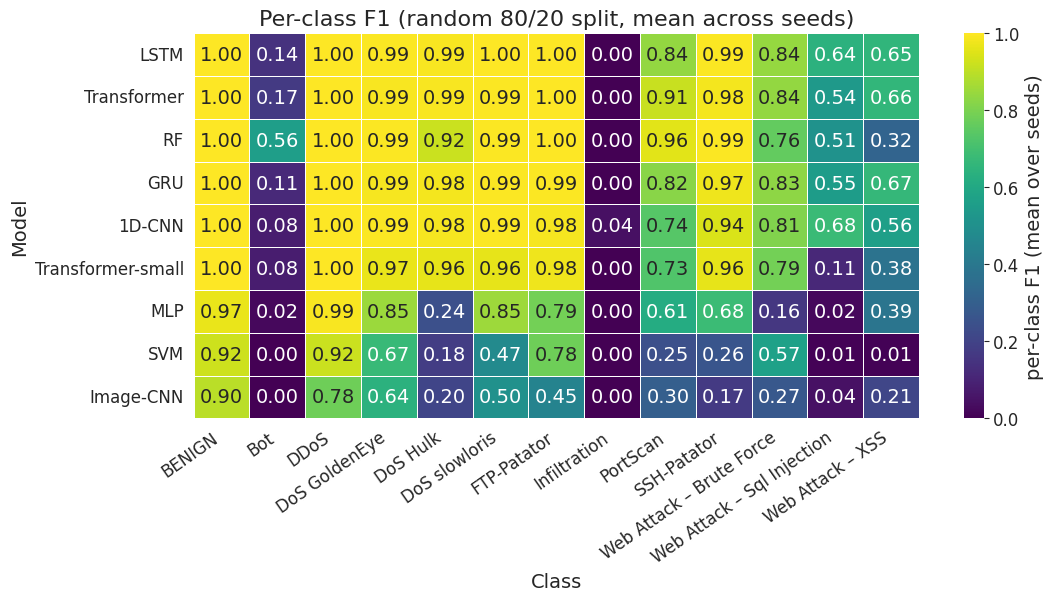

In [ ]:
# per-class F1 heatmap (PDF)
fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(CLASS_NAMES)), max(5, 0.55 * len(mean_pc))))
sns.heatmap(mean_pc, annot=True, fmt='.2f', cmap='viridis',
            cbar_kws={'label': 'per-class F1 (mean over seeds)'},
            linewidths=0.4, linecolor='white', ax=ax,
            vmin=0.0, vmax=1.0)
ax.set_title('Per-class F1 (random 80/20 split, mean across seeds)')
ax.set_xlabel('Class')
ax.set_ylabel('Model')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
save_fig(fig, 'fig_per_class_f1_random_v4')
plt.show()

Best model by mean macro-F1: LSTM


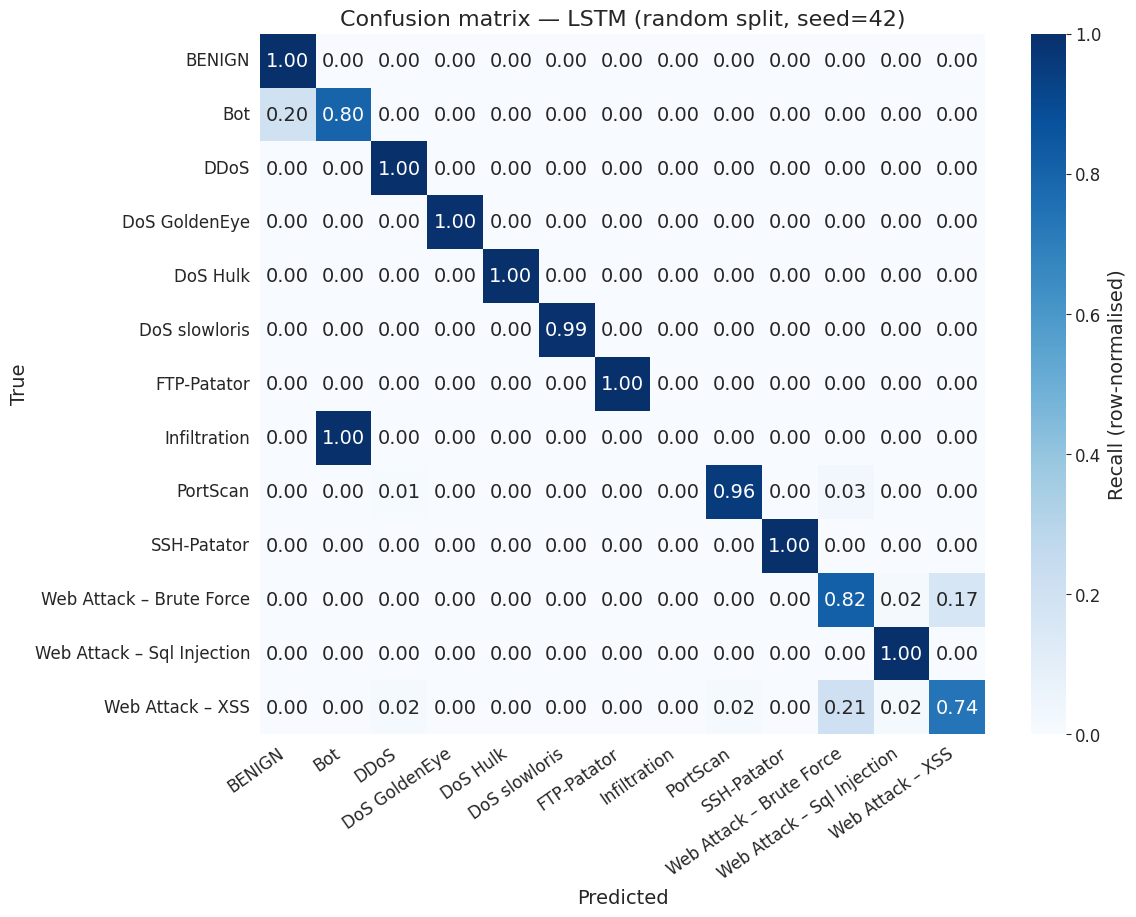

In [ ]:
# confusion matrix for the best model (mean-F1 winner) — using seed=42 run
best_model = random_summary_df.iloc[0]['model']
print(f'Best model by mean macro-F1: {best_model}')
# Re-run best model on seed 42 just for the CM (cheap; ensures reproducibility).
# Re-set global seed inside this helper so each call is independent of
# whatever previous cell mutated TF's RNG state.
def _cm_from_run(model_name, seed=42):
    set_global_seed(seed)
    if model_name == 'SVM':            yt, yp, _, _ = train_svm(seed)
    elif model_name == 'RF':           yt, yp, _, _ = train_rf(seed)
    elif model_name == 'MLP':          yt, yp, _, _ = train_mlp(seed)
    elif model_name == 'Image-CNN':    yt, yp, _, _ = train_image_cnn(seed)
    elif model_name == 'LSTM':         yt, yp, _, _ = _train_temporal(seed, build_lstm,  LR_LSTM)
    elif model_name == 'GRU':          yt, yp, _, _ = _train_temporal(seed, build_gru,   LR_GRU)
    elif model_name == '1D-CNN':       yt, yp, _, _ = _train_temporal(seed, build_cnn1d, LR_CNN1D)
    elif model_name == 'Transformer':  yt, yp, _, _ = _train_transformer(seed, build_transformer)
    elif model_name == 'Transformer-small': yt, yp, _, _ = _train_transformer(seed, build_transformer_small)
    else: raise ValueError(model_name)
    return yt, yp

yt_cm, yp_cm = _cm_from_run(best_model)
cm = confusion_matrix(yt_cm, yp_cm, labels=list(range(NUM_CLASSES)), normalize='true')
fig, ax = plt.subplots(figsize=(max(10, 0.9 * NUM_CLASSES), max(8, 0.7 * NUM_CLASSES)))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES, ax=ax, vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Recall (row-normalised)'})
ax.set_title(f'Confusion matrix — {best_model} (random split, seed=42)')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
save_fig(fig, f'fig_cm_{best_model.lower().replace("-", "_")}_v4')
plt.show()
free_memory()

---
## Inference latency vs $T$

Untrained models on random tensors (forward-pass cost only). The builders
below mirror the trained architectures layer-for-layer (BatchNorm and Dropout
included; Dropout is inactive at inference). RF CPU latency is **measured**
in the Pareto cell.
Two figure variants saved as PDF:
- **Primary**: scatter + inset zoom showing the squashed LSTM/GRU/1D-CNN cluster
- **Backup**: grouped bar chart with std error bars


In [ ]:
# minimal builders (no compile, no class weights) — layer-for-layer copies of
# the trained architectures so the measured cost is the real inference cost
def _lat_lstm(T, num_classes=NUM_CLASSES):
    return models.Sequential([
        layers.Input(shape=(T, F)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])

def _lat_gru(T, num_classes=NUM_CLASSES):
    return models.Sequential([
        layers.Input(shape=(T, F)),
        layers.GRU(64, return_sequences=True),
        layers.GRU(32),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])

def _lat_cnn1d(T, num_classes=NUM_CLASSES):
    return models.Sequential([
        layers.Input(shape=(T, F)),
        layers.Conv1D(64,  3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Conv1D(128, 3, activation='relu', padding='same'), layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax'),
    ])

def _lat_trans(T, side, num_classes=NUM_CLASSES):
    cnn = cnn_extractor(side, EMBED_DIM)
    inp = layers.Input(shape=(T, side, side, 1))
    x = layers.TimeDistributed(cnn)(inp)
    x = PositionalEncoding(T, EMBED_DIM)(x)
    x = CLSToken(EMBED_DIM)(x)
    for _ in range(NUM_BLOCKS):
        x = TransformerBlock(EMBED_DIM, NUM_HEADS, FF_DIM)(x)
    cls_out = layers.Lambda(lambda t: t[:, 0, :])(x)
    cls_out = layers.Dropout(0.3)(cls_out)
    out = layers.Dense(num_classes, activation='softmax')(cls_out)
    return models.Model(inp, out)


In [ ]:
# run benchmark
side = int(np.ceil(np.sqrt(F)))  # 9
lat_rows = []
for T in LAT_T_VALS:
    seq = tf.constant(np.random.randn(LAT_BATCH, T, F).astype(np.float32))
    img = tf.constant(np.random.rand (LAT_BATCH, T, side, side, 1).astype(np.float32))
    for name, builder, X_in in [
        ('LSTM',        lambda T_: _lat_lstm(T_),        seq),
        ('GRU',         lambda T_: _lat_gru(T_),         seq),
        ('1D-CNN',      lambda T_: _lat_cnn1d(T_),       seq),
        ('Transformer', lambda T_: _lat_trans(T_, side), img),
    ]:
        m = builder(T)
        _ = m(X_in, training=False)              # warmup (graph-trace)
        ts = []
        for _ in range(LAT_REPEATS):
            t0 = time.time(); _ = m(X_in, training=False); ts.append(time.time() - t0)
        ms_per_sample = 1000 * np.array(ts) / LAT_BATCH
        lat_rows.append({
            'T': T, 'Model': name,
            'latency_ms_mean': float(np.mean(ms_per_sample)),
            'latency_ms_std':  float(np.std (ms_per_sample, ddof=1) if len(ms_per_sample) > 1 else 0.0),
            'n_repeats': LAT_REPEATS,
        })
        print(f'T={T:>2} {name:11s} {np.mean(ms_per_sample):.3f} ± {np.std(ms_per_sample, ddof=1):.3f} ms/sample')
        del m
        free_memory()

lat_df = pd.DataFrame(lat_rows)
lat_df.to_csv(os.path.join(FIG_DIR, 'latency.csv'), index=False)

T= 5 LSTM        0.132 ± 0.003 ms/sample
T= 5 GRU         0.122 ± 0.003 ms/sample
T= 5 1D-CNN      0.086 ± 0.002 ms/sample
T= 5 Transformer 0.646 ± 0.009 ms/sample
T=10 LSTM        0.132 ± 0.004 ms/sample
T=10 GRU         0.121 ± 0.003 ms/sample
T=10 1D-CNN      0.089 ± 0.003 ms/sample
T=10 Transformer 1.013 ± 0.010 ms/sample
T=20 LSTM        0.135 ± 0.001 ms/sample
T=20 GRU         0.118 ± 0.001 ms/sample
T=20 1D-CNN      0.087 ± 0.003 ms/sample
T=20 Transformer 1.732 ± 0.007 ms/sample
T=30 LSTM        0.136 ± 0.001 ms/sample
T=30 GRU         0.125 ± 0.002 ms/sample
T=30 1D-CNN      0.088 ± 0.002 ms/sample
T=30 Transformer 2.456 ± 0.012 ms/sample
T=50 LSTM        0.140 ± 0.001 ms/sample
T=50 GRU         0.128 ± 0.003 ms/sample
T=50 1D-CNN      0.085 ± 0.001 ms/sample
T=50 Transformer 3.895 ± 0.024 ms/sample


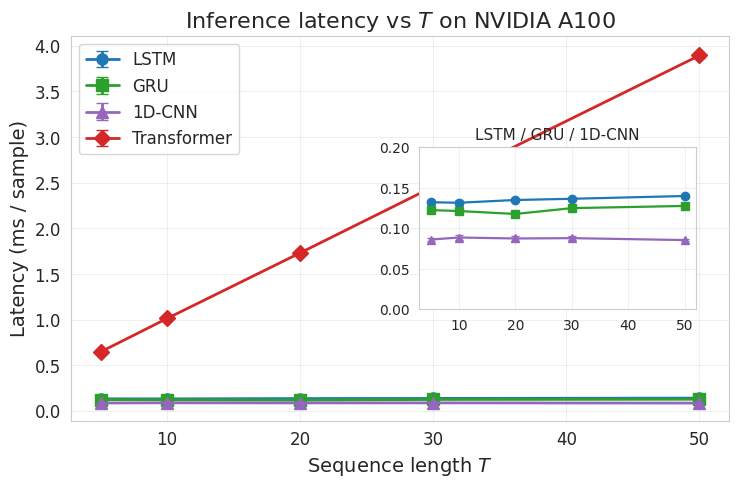

In [ ]:
# PRIMARY FIGURE — scatter + inset zoom
order = ['LSTM', 'GRU', '1D-CNN', 'Transformer']
markers = {'LSTM': 'o', 'GRU': 's', '1D-CNN': '^', 'Transformer': 'D'}
colors  = {'LSTM': '#1f77b4', 'GRU': '#2ca02c', '1D-CNN': '#9467bd', 'Transformer': '#d62728'}

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for name in order:
    sub = lat_df[lat_df['Model'] == name].sort_values('T')
    ax.errorbar(sub['T'], sub['latency_ms_mean'], yerr=sub['latency_ms_std'],
                marker=markers[name], color=colors[name], linewidth=2.0,
                markersize=8, capsize=4, label=name)
ax.set_xlabel('Sequence length $T$')
ax.set_ylabel('Latency (ms / sample)')
ax.set_title('Inference latency vs $T$ on NVIDIA A100')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

# Inset: zoom into the LSTM/GRU/1D-CNN cluster (<0.2 ms) that gets squashed
axins = inset_axes(ax, width='42%', height='42%', loc='center right', borderpad=2.0)
for name in ['LSTM', 'GRU', '1D-CNN']:
    sub = lat_df[lat_df['Model'] == name].sort_values('T')
    axins.errorbar(sub['T'], sub['latency_ms_mean'], yerr=sub['latency_ms_std'],
                   marker=markers[name], color=colors[name], linewidth=1.6,
                   markersize=6, capsize=3, label=name)
axins.set_ylim(0.0, 0.20)
axins.set_xlim(min(LAT_T_VALS) - 2, max(LAT_T_VALS) + 2)
axins.set_title('LSTM / GRU / 1D-CNN', fontsize=11)
axins.tick_params(axis='both', labelsize=10)
axins.grid(True, alpha=0.3)

save_fig(fig, 'fig_latency_v4')
plt.show()

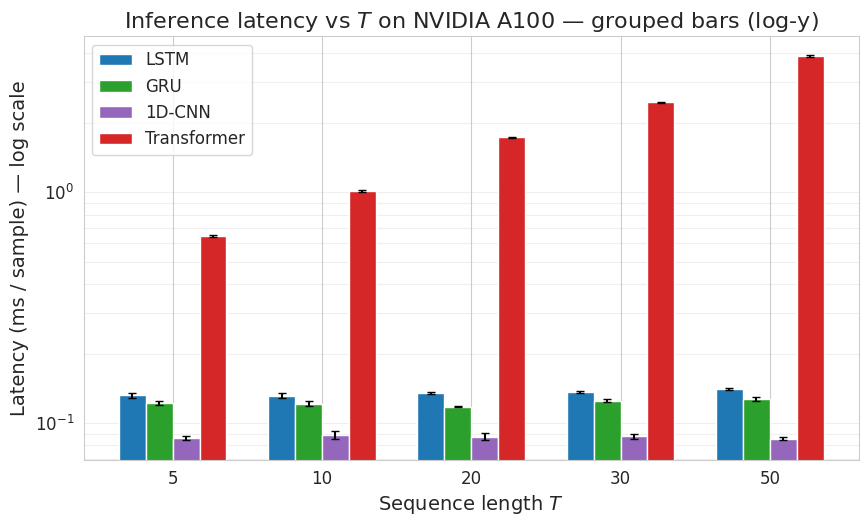

In [ ]:
# BACKUP FIGURE — grouped bar with std error bars
fig, ax = plt.subplots(figsize=(10, 5.5))
T_arr = np.array(LAT_T_VALS)
n_models = len(order)
width = 0.18
xs = np.arange(len(T_arr))
for i, name in enumerate(order):
    sub = lat_df[lat_df['Model'] == name].sort_values('T').reset_index(drop=True)
    means = sub['latency_ms_mean'].values
    stds  = sub['latency_ms_std' ].values
    ax.bar(xs + (i - (n_models - 1) / 2) * width, means, width,
           yerr=stds, capsize=3, color=colors[name], label=name)
ax.set_xticks(xs)
ax.set_xticklabels([str(t) for t in T_arr])
ax.set_xlabel('Sequence length $T$')
ax.set_ylabel('Latency (ms / sample) — log scale')
ax.set_yscale('log')
ax.set_title('Inference latency vs $T$ on NVIDIA A100 — grouped bars (log-y)')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, axis='y', which='both', alpha=0.3)
save_fig(fig, 'fig_latency_bars_v4')
plt.show()

---
## Pareto: cost (latency at $T=20$) vs accuracy (random-split mean macro-F1)

RF latency is **measured** on CPU with the same 128-sample batch and repeat
count as the GPU benchmark (train once on the standard subsample, then time
`predict`). PDF.


RF (CPU, measured): 0.273 ± 0.017 ms/sample


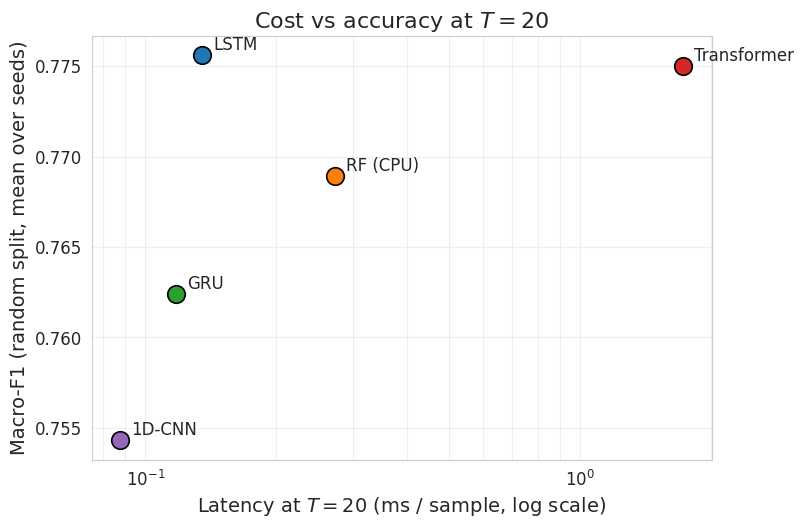

In [ ]:
# Pareto plot — GPU latency for the temporal models, measured CPU latency for RF
lat_T20 = lat_df[lat_df['T'] == 20].set_index('Model')
acc_map = random_summary_df.set_index('model')['f1_macro_mean']

# measure RF CPU inference latency
(Xtr_rf, ytr_rf, _), (Xte_rf, _, _), _ = _split_and_scale(42)
Xtr_rf_l, Xte_rf_l = Xtr_rf[:, -1, :], Xte_rf[:, -1, :]
idx_rf = cap_per_class(ytr_rf, RF_CAP, 42)
rf_m = build_rf(42)
rf_m.fit(Xtr_rf_l[idx_rf], ytr_rf[idx_rf])
batch = Xte_rf_l[:LAT_BATCH]
_ = rf_m.predict(batch)                                   # warmup
ts = []
for _ in range(LAT_REPEATS):
    t0 = time.time(); _ = rf_m.predict(batch); ts.append(time.time() - t0)
rf_ms     = 1000 * float(np.mean(ts)) / LAT_BATCH
rf_ms_std = 1000 * float(np.std(ts, ddof=1)) / LAT_BATCH
print(f'RF (CPU, measured): {rf_ms:.3f} ± {rf_ms_std:.3f} ms/sample')
del rf_m, Xtr_rf, Xte_rf, Xtr_rf_l, Xte_rf_l, idx_rf, batch
free_memory()

pareto_rows = []
for name in ['LSTM', 'GRU', '1D-CNN', 'Transformer']:
    if name in acc_map.index and name in lat_T20.index:
        pareto_rows.append({'model': name,
                            'latency_ms':     lat_T20.loc[name, 'latency_ms_mean'],
                            'latency_ms_std': lat_T20.loc[name, 'latency_ms_std'],
                            'macro_f1':       acc_map.loc[name]})
if 'RF' in acc_map.index:
    pareto_rows.append({'model': 'RF (CPU)', 'latency_ms': rf_ms,
                        'latency_ms_std': rf_ms_std, 'macro_f1': acc_map.loc['RF']})
pareto_df = pd.DataFrame(pareto_rows)
pareto_df.to_csv(os.path.join(FIG_DIR, 'pareto.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
for _, r in pareto_df.iterrows():
    name = r['model']
    base = name.split(' ')[0]
    c = colors.get(base, '#ff7f0e')
    ax.scatter(r['latency_ms'], r['macro_f1'], s=160, color=c, edgecolor='black', linewidth=1.2, zorder=3)
    ax.annotate(name, (r['latency_ms'], r['macro_f1']), xytext=(8, 4),
                textcoords='offset points', fontsize=12)
ax.set_xscale('log')
ax.set_xlabel('Latency at $T{=}20$ (ms / sample, log scale)')
ax.set_ylabel('Macro-F1 (random split, mean over seeds)')
ax.set_title('Cost vs accuracy at $T=20$')
ax.grid(True, which='both', alpha=0.3)
save_fig(fig, 'fig_pareto_v4')
plt.show()


---
## Static models on the full 15-class flow data

Re-train SVM, RF, MLP, image-CNN with no windowing, per-class cap = 25k. 3 seeds.
Bar chart with std error bars (PDF).

In [ ]:
# prep flow-level data
X_flat = df[feat_cols].values.astype(np.float32)
y_flat = df['label_enc'].values
N15    = NUM_CLASSES_15

ALL_AGG_STATIC15 = []
ALL_PS_STATIC15  = []
ALL_PC_STATIC15  = []

def _static15_split(seed):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(X_flat))
    cut  = int(TRAIN_RATIO * len(X_flat))
    tr_idx, te_idx = perm[:cut], perm[cut:]
    Xtr, ytr = X_flat[tr_idx], y_flat[tr_idx]
    Xte, yte = X_flat[te_idx], y_flat[te_idx]
    # cap per class
    cap_idx = []
    for c in np.unique(ytr):
        ci = np.where(ytr == c)[0]
        if len(ci) > STATIC15_CAP:
            ci = rng.choice(ci, STATIC15_CAP, replace=False)
        cap_idx.extend(ci)
    cap_idx = np.array(sorted(cap_idx))
    Xtr_c, ytr_c = Xtr[cap_idx], ytr[cap_idx]
    print(f'    static15 subsample: {len(ytr_c):,} of {len(ytr):,} training flows (cap {STATIC15_CAP:,}/class)')
    sc = StandardScaler().fit(Xtr_c)
    return (sc.transform(Xtr_c), ytr_c), (sc.transform(Xte), yte)

In [ ]:
# SVM-15
def train_svm15(seed):
    (Xtr, ytr), (Xte, yte) = _static15_split(seed)
    m = build_svm(seed)
    t0 = time.time()
    m.fit(Xtr, ytr)
    t = time.time() - t0
    yp = m.predict(Xte)
    return yte, yp, None, t
ps, pc, ag = run_seeds('static15', 'SVM-15', train_svm15, SEEDS, N15, CLASS_NAMES_15)
ALL_PS_STATIC15 += ps; ALL_PC_STATIC15 += pc; ALL_AGG_STATIC15.append(ag)

    static15 subsample: 131,663 of 2,262,141 training flows (cap 25,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM-15] seed=2: F1m=0.3866 acc=0.8339 rec_m=0.8033  (1611.2s train)
    static15 subsample: 131,788 of 2,262,141 training flows (cap 25,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM-15] seed=42: F1m=0.363 acc=0.8049 rec_m=0.7867  (1339.3s train)
    static15 subsample: 131,815 of 2,262,141 training flows (cap 25,000/class)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM-15] seed=123: F1m=0.3399 acc=0.7913 rec_m=0.8259  (1867.0s train)


In [ ]:
# RF-15
def train_rf15(seed):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(X_flat))
    cut = int(TRAIN_RATIO * len(X_flat))
    tr_idx, te_idx = perm[:cut], perm[cut:]
    Xtr, ytr = X_flat[tr_idx], y_flat[tr_idx]
    Xte, yte = X_flat[te_idx], y_flat[te_idx]
    cap_idx = []
    for c in np.unique(ytr):
        ci = np.where(ytr == c)[0]
        if len(ci) > STATIC15_CAP:
            ci = rng.choice(ci, STATIC15_CAP, replace=False)
        cap_idx.extend(ci)
    cap_idx = np.array(sorted(cap_idx))
    Xtr_c, ytr_c = Xtr[cap_idx], ytr[cap_idx]
    print(f'    static15 subsample: {len(ytr_c):,} of {len(ytr):,} training flows (cap {STATIC15_CAP:,}/class)')
    m = build_rf(seed)
    t0 = time.time()
    m.fit(Xtr_c, ytr_c)
    t = time.time() - t0
    yp = m.predict(Xte)
    pr = m.predict_proba(Xte)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('static15', 'RF-15', train_rf15, SEEDS, N15, CLASS_NAMES_15)
ALL_PS_STATIC15 += ps; ALL_PC_STATIC15 += pc; ALL_AGG_STATIC15.append(ag)

    static15 subsample: 131,663 of 2,262,141 training flows (cap 25,000/class)
  [RF-15] seed=2: F1m=0.8351 acc=0.9921 rec_m=0.9365  (4.8s train)
    static15 subsample: 131,788 of 2,262,141 training flows (cap 25,000/class)
  [RF-15] seed=42: F1m=0.7829 acc=0.991 rec_m=0.8826  (4.8s train)
    static15 subsample: 131,815 of 2,262,141 training flows (cap 25,000/class)
  [RF-15] seed=123: F1m=0.7842 acc=0.9929 rec_m=0.9067  (4.8s train)


In [ ]:
# MLP-15
def train_mlp15(seed):
    (Xtr, ytr), (Xte, yte) = _static15_split(seed)
    cw = class_weight_dict(ytr, N15)
    es, rl = make_callbacks()
    m = build_mlp(F, N15)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('static15', 'MLP-15', train_mlp15, SEEDS, N15, CLASS_NAMES_15)
ALL_PS_STATIC15 += ps; ALL_PC_STATIC15 += pc; ALL_AGG_STATIC15.append(ag)

    static15 subsample: 131,663 of 2,262,141 training flows (cap 25,000/class)
  [MLP-15] seed=2: F1m=0.4941 acc=0.8822 rec_m=0.844  (31.0s train)
    static15 subsample: 131,788 of 2,262,141 training flows (cap 25,000/class)
  [MLP-15] seed=42: F1m=0.4926 acc=0.8721 rec_m=0.8561  (30.1s train)
    static15 subsample: 131,815 of 2,262,141 training flows (cap 25,000/class)
  [MLP-15] seed=123: F1m=0.4741 acc=0.8583 rec_m=0.8683  (30.2s train)


In [ ]:
# CNN-image-15
def train_imagecnn15(seed):
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(X_flat))
    cut = int(TRAIN_RATIO * len(X_flat))
    tr_idx, te_idx = perm[:cut], perm[cut:]
    Xtr_raw, ytr = X_flat[tr_idx], y_flat[tr_idx]
    Xte_raw, yte = X_flat[te_idx], y_flat[te_idx]
    cap_idx = []
    for c in np.unique(ytr):
        ci = np.where(ytr == c)[0]
        if len(ci) > STATIC15_CAP:
            ci = rng.choice(ci, STATIC15_CAP, replace=False)
        cap_idx.extend(ci)
    cap_idx = np.array(sorted(cap_idx))
    Xtr_c, ytr_c = Xtr_raw[cap_idx], ytr[cap_idx]
    side = int(math.ceil(math.sqrt(F)))
    n_pad = side * side - F
    mm = MinMaxScaler().fit(Xtr_c)
    def to_img(M):
        flat = mm.transform(M).astype(np.float32)
        flat = np.pad(flat, ((0, 0), (0, n_pad)), mode='constant')
        return flat.reshape(-1, side, side, 1)
    Xtr_img = to_img(Xtr_c); Xte_img = to_img(Xte_raw)
    cw = class_weight_dict(ytr_c, N15)
    es, rl = make_callbacks()
    m = build_image_cnn(side, N15)
    t0 = time.time()
    m.fit(Xtr_img, ytr_c, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_img, verbose=0)
    yp = np.argmax(pr, axis=1)
    return yte, yp, pr, t
ps, pc, ag = run_seeds('static15', 'CNN-image-15', train_imagecnn15, SEEDS, N15, CLASS_NAMES_15)
ALL_PS_STATIC15 += ps; ALL_PC_STATIC15 += pc; ALL_AGG_STATIC15.append(ag)

  [CNN-image-15] seed=2: F1m=0.4908 acc=0.8842 rec_m=0.8297  (25.8s train)
  [CNN-image-15] seed=42: F1m=0.4985 acc=0.8798 rec_m=0.8613  (25.6s train)
  [CNN-image-15] seed=123: F1m=0.4412 acc=0.8614 rec_m=0.8543  (25.1s train)


experiment        model  n_seeds  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  recall_macro_mean  recall_macro_std  precision_macro_mean  precision_macro_std  fpr_mean  fpr_std  fnr_mean  fnr_std  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std  train_seconds_mean  train_seconds_std
  static15        RF-15        3         0.9920        0.0010         0.8007        0.0298            0.9939           0.0006             0.9086            0.0270                0.7635               0.0331    0.0094   0.0012    0.0006   0.0001        0.9983       0.0017       0.8576      0.0044              4.8033             0.0153
  static15       MLP-15        3         0.8709        0.0120         0.4869        0.0111            0.9041           0.0101             0.8561            0.0122                0.4249               0.0232    0.1593   0.0152    0.0015   0.0010        0.9934       0.0014       0.6608      0.0136             30.4667             0.

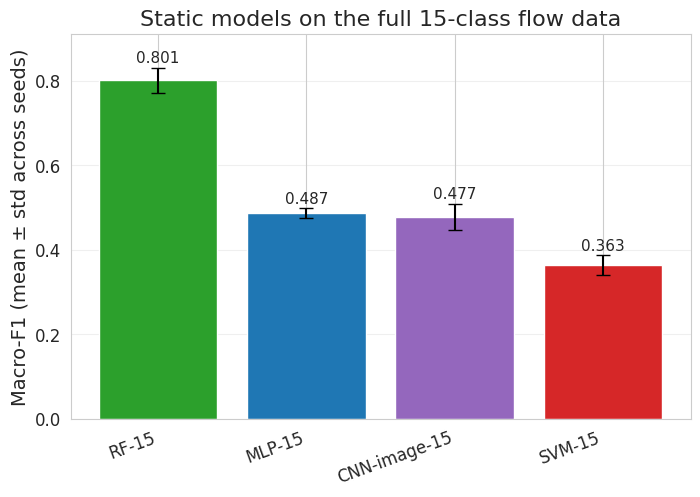

In [ ]:
# Static-15 summary + bar chart with std (PDF)
static15_summary = pd.DataFrame(ALL_AGG_STATIC15).sort_values('f1_macro_mean', ascending=False)
static15_summary.to_csv(os.path.join(FIG_DIR, 'static15_summary.csv'), index=False)
print(static15_summary.to_string(index=False))

pd.DataFrame(ALL_PS_STATIC15).to_csv(os.path.join(FIG_DIR, 'static15_per_seed.csv'), index=False)
pd.DataFrame(ALL_PC_STATIC15).to_csv(os.path.join(FIG_DIR, 'static15_per_class_per_seed.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
mods   = static15_summary['model'].tolist()
means  = static15_summary['f1_macro_mean'].values
stds   = static15_summary['f1_macro_std' ].values
xs = np.arange(len(mods))
bars = ax.bar(xs, means, yerr=stds, capsize=5,
              color=['#2ca02c', '#1f77b4', '#9467bd', '#d62728'][:len(mods)])
for x, m, s in zip(xs, means, stds):
    ax.text(x, m + s + 0.012, f'{m:.3f}', ha='center', fontsize=11)
ax.set_xticks(xs); ax.set_xticklabels(mods, rotation=20, ha='right')
ax.set_ylabel('Macro-F1 (mean ± std across seeds)')
ax.set_ylim(0, max(means + stds) + 0.08)
ax.set_title('Static models on the full 15-class flow data')
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_static15_v4')
plt.show()
free_memory()

---
## Padding ablation: zero-pad + mask

Re-trains LSTM/GRU/1D-CNN with `Masking(mask_value=0.0)` and Transformer/Trans-small with the masked variant. 3 seeds.

In [ ]:
# zero-pad + mask preparation per seed
def _zp_split_and_scale(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), present = stratified_split(X_zp, y_zp, M_zp, seed)
    sc = fit_zscore(Xtr, mask=Mtr)
    Xtr = apply_zscore(sc, Xtr, mask=Mtr)
    Xte = apply_zscore(sc, Xte, mask=Mte)
    mm, side, n_pad = fit_image_enc(Xtr, mask=Mtr)
    Xtr_img = encode_imgs(mm, Xtr, side, n_pad, mask=Mtr)
    Xte_img = encode_imgs(mm, Xte, side, n_pad, mask=Mte)
    return (Xtr, ytr, Mtr), (Xte, yte, Mte), (Xtr_img, Xte_img, side)

def train_lstm_zp(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), _ = _zp_split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_lstm(TIMESTEPS, F, NUM_CLASSES, lr=LR_LSTM, mask=True)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_gru_zp(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), _ = _zp_split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_gru(TIMESTEPS, F, NUM_CLASSES, lr=LR_GRU, mask=True)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_cnn1d_zp(seed):
    # Conv1D cannot consume a Keras mask (it would be silently discarded),
    # so the 1D-CNN sees the zero-padded inputs themselves; LSTM/GRU use
    # Masking and the Transformers use an explicit attention mask.
    (Xtr, ytr, Mtr), (Xte, yte, Mte), _ = _zp_split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_cnn1d(TIMESTEPS, F, NUM_CLASSES, lr=LR_CNN1D, mask=False)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_trans_zp(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), (Xtr_img, Xte_img, side) = _zp_split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_masked_transformer(TIMESTEPS, side, NUM_CLASSES)
    t0 = time.time()
    m.fit([Xtr_img, Mtr], ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict([Xte_img, Mte], verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_trans_small_zp(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), (Xtr_img, Xte_img, side) = _zp_split_and_scale(seed)
    cw = class_weight_dict(ytr, NUM_CLASSES)
    es, rl = make_callbacks()
    m = build_masked_transformer_small(TIMESTEPS, side, NUM_CLASSES)
    t0 = time.time()
    m.fit([Xtr_img, Mtr], ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict([Xte_img, Mte], verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

In [ ]:
# run all 5 zero-pad models
ALL_AGG_PADDING = []
ALL_PS_PADDING  = []
ALL_PC_PADDING  = []

for label, fn in [('LSTM-ZP',              train_lstm_zp),
                  ('GRU-ZP',               train_gru_zp),
                  ('1D-CNN-ZP',            train_cnn1d_zp),
                  ('Transformer-ZP',       train_trans_zp),
                  ('Transformer-small-ZP', train_trans_small_zp)]:
    ps, pc, ag = run_seeds('padding_zp', label, fn, SEEDS, NUM_CLASSES, CLASS_NAMES)
    ALL_AGG_PADDING.append(ag); ALL_PS_PADDING += ps; ALL_PC_PADDING += pc

padding_summary = pd.DataFrame(ALL_AGG_PADDING)
padding_summary.to_csv(os.path.join(FIG_DIR, 'padding_summary.csv'), index=False)
pd.DataFrame(ALL_PS_PADDING).to_csv(os.path.join(FIG_DIR, 'padding_per_seed.csv'),           index=False)
pd.DataFrame(ALL_PC_PADDING).to_csv(os.path.join(FIG_DIR, 'padding_per_class_per_seed.csv'), index=False)
print(padding_summary.to_string(index=False))


  [LSTM-ZP] seed=2: F1m=0.7607 acc=0.9977 rec_m=0.8624  (141.8s train)
  [LSTM-ZP] seed=42: F1m=0.7475 acc=0.997 rec_m=0.9384  (133.7s train)
  [LSTM-ZP] seed=123: F1m=0.7686 acc=0.998 rec_m=0.932  (115.6s train)
  [GRU-ZP] seed=2: F1m=0.7307 acc=0.9964 rec_m=0.865  (128.7s train)
  [GRU-ZP] seed=42: F1m=0.756 acc=0.9971 rec_m=0.9431  (139.2s train)
  [GRU-ZP] seed=123: F1m=0.7435 acc=0.9948 rec_m=0.9343  (112.5s train)
  [1D-CNN-ZP] seed=2: F1m=0.7079 acc=0.9961 rec_m=0.8592  (44.8s train)
  [1D-CNN-ZP] seed=42: F1m=0.6771 acc=0.9937 rec_m=0.8023  (38.4s train)
  [1D-CNN-ZP] seed=123: F1m=0.7395 acc=0.9977 rec_m=0.8956  (57.2s train)
  [Transformer-ZP] seed=2: F1m=0.5679 acc=0.9649 rec_m=0.7004  (230.9s train)
  [Transformer-ZP] seed=42: F1m=0.5086 acc=0.98 rec_m=0.5987  (268.6s train)
  [Transformer-ZP] seed=123: F1m=0.5204 acc=0.9732 rec_m=0.6693  (232.7s train)
  [Transformer-small-ZP] seed=2: F1m=0.4779 acc=0.9409 rec_m=0.6874  (186.3s train)
  [Transformer-small-ZP] seed=42: F1m=

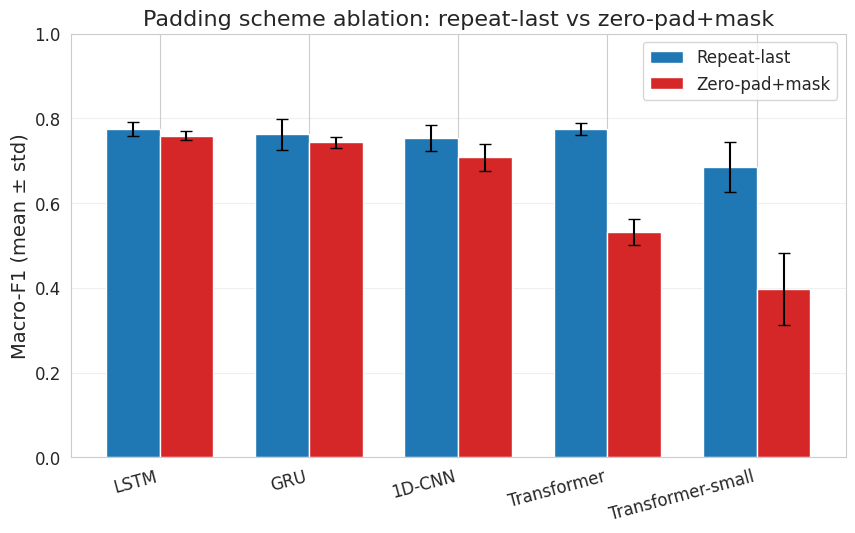

In [ ]:
# padding ablation chart (repeat-last vs zero-pad+mask, with std)
# Repeat-last numbers from the random-split cells above random summary
repeat_last_map = {
    'LSTM':              random_summary_df.set_index('model').loc['LSTM',              'f1_macro_mean'] if 'LSTM' in random_summary_df['model'].values else float('nan'),
    'GRU':               random_summary_df.set_index('model').loc['GRU',               'f1_macro_mean'] if 'GRU' in random_summary_df['model'].values else float('nan'),
    '1D-CNN':            random_summary_df.set_index('model').loc['1D-CNN',            'f1_macro_mean'] if '1D-CNN' in random_summary_df['model'].values else float('nan'),
    'Transformer':       random_summary_df.set_index('model').loc['Transformer',       'f1_macro_mean'] if 'Transformer' in random_summary_df['model'].values else float('nan'),
    'Transformer-small': random_summary_df.set_index('model').loc['Transformer-small', 'f1_macro_mean'] if 'Transformer-small' in random_summary_df['model'].values else float('nan'),
}
repeat_last_std = {
    'LSTM':              random_summary_df.set_index('model').loc['LSTM',              'f1_macro_std' ] if 'LSTM' in random_summary_df['model'].values else 0.0,
    'GRU':               random_summary_df.set_index('model').loc['GRU',               'f1_macro_std' ] if 'GRU' in random_summary_df['model'].values else 0.0,
    '1D-CNN':            random_summary_df.set_index('model').loc['1D-CNN',            'f1_macro_std' ] if '1D-CNN' in random_summary_df['model'].values else 0.0,
    'Transformer':       random_summary_df.set_index('model').loc['Transformer',       'f1_macro_std' ] if 'Transformer' in random_summary_df['model'].values else 0.0,
    'Transformer-small': random_summary_df.set_index('model').loc['Transformer-small', 'f1_macro_std' ] if 'Transformer-small' in random_summary_df['model'].values else 0.0,
}
zp_map = {r['model'].replace('-ZP', ''): r['f1_macro_mean'] for _, r in padding_summary.iterrows()}
zp_std = {r['model'].replace('-ZP', ''): r['f1_macro_std' ] for _, r in padding_summary.iterrows()}

mods = ['LSTM', 'GRU', '1D-CNN', 'Transformer', 'Transformer-small']
xs = np.arange(len(mods))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(xs - width/2, [repeat_last_map[m] for m in mods],
       width, yerr=[repeat_last_std[m] for m in mods],
       capsize=4, label='Repeat-last',   color='#1f77b4')
ax.bar(xs + width/2, [zp_map.get(m, np.nan) for m in mods],
       width, yerr=[zp_std.get(m, 0.0) for m in mods],
       capsize=4, label='Zero-pad+mask', color='#d62728')
ax.set_xticks(xs); ax.set_xticklabels(mods, rotation=15, ha='right')
ax.set_ylabel('Macro-F1 (mean ± std)')
ax.set_title('Padding scheme ablation: repeat-last vs zero-pad+mask')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_padding_ablation_v4')
plt.show()
free_memory()

---
## Non-padded subset

Filter to windows with mask sum == 20 (no padding); 9 of 13 classes survive (drops Bot, FTP-Patator, Infiltration, SSH-Patator). 3 seeds.

In [ ]:
# non-padded subset prep
def _nopad_subset(seed):
    (Xtr, ytr, Mtr), (Xte, yte, Mte), _ = _zp_split_and_scale(seed)
    real_tr = (Mtr.sum(axis=1) == TIMESTEPS)
    real_te = (Mte.sum(axis=1) == TIMESTEPS)
    Xtr_n, ytr_n = Xtr[real_tr], ytr[real_tr]
    Xte_n, yte_n = Xte[real_te], yte[real_te]
    # Drop classes missing from either side, remap
    present = sorted(set(np.unique(ytr_n)) & set(np.unique(yte_n)))
    rmap = {old: new for new, old in enumerate(present)}
    keep_tr = np.isin(ytr_n, present); keep_te = np.isin(yte_n, present)
    Xtr_n, ytr_n = Xtr_n[keep_tr], np.array([rmap[v] for v in ytr_n[keep_tr]])
    Xte_n, yte_n = Xte_n[keep_te], np.array([rmap[v] for v in yte_n[keep_te]])
    return (Xtr_n, ytr_n), (Xte_n, yte_n), present

def train_lstm_nopad(seed):
    (Xtr, ytr), (Xte, yte), present = _nopad_subset(seed)
    n_class = len(present)
    cw = class_weight_dict(ytr, n_class)
    es, rl = make_callbacks()
    m = build_lstm(TIMESTEPS, F, n_class, lr=LR_LSTM)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_gru_nopad(seed):
    (Xtr, ytr), (Xte, yte), present = _nopad_subset(seed)
    n_class = len(present)
    cw = class_weight_dict(ytr, n_class)
    es, rl = make_callbacks()
    m = build_gru(TIMESTEPS, F, n_class, lr=LR_GRU)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_cnn1d_nopad(seed):
    (Xtr, ytr), (Xte, yte), present = _nopad_subset(seed)
    n_class = len(present)
    cw = class_weight_dict(ytr, n_class)
    es, rl = make_callbacks()
    m = build_cnn1d(TIMESTEPS, F, n_class, lr=LR_CNN1D)
    t0 = time.time()
    m.fit(Xtr, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def _nopad_imgs(seed):
    (Xtr, ytr), (Xte, yte), present = _nopad_subset(seed)
    side = int(math.ceil(math.sqrt(F)))
    n_pad = side * side - F
    mm = MinMaxScaler().fit(Xtr.reshape(-1, F))
    def to_img(X):
        n, T, _ = X.shape
        flat = mm.transform(X.reshape(-1, F)).astype(np.float32)
        flat = np.pad(flat, ((0, 0), (0, n_pad)), mode='constant')
        return flat.reshape(n, T, side, side, 1)
    return (to_img(Xtr), ytr), (to_img(Xte), yte), len(present), side

def train_trans_nopad(seed):
    (Xtr_img, ytr), (Xte_img, yte), n_class, side = _nopad_imgs(seed)
    cw = class_weight_dict(ytr, n_class)
    es, rl = make_callbacks()
    m = build_transformer(TIMESTEPS, side, n_class)
    t0 = time.time()
    m.fit(Xtr_img, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_img, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

def train_trans_small_nopad(seed):
    (Xtr_img, ytr), (Xte_img, yte), n_class, side = _nopad_imgs(seed)
    cw = class_weight_dict(ytr, n_class)
    es, rl = make_callbacks()
    m = build_transformer_small(TIMESTEPS, side, n_class)
    t0 = time.time()
    m.fit(Xtr_img, ytr, validation_split=0.15, epochs=EPOCHS,
          batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
    t = time.time() - t0
    pr = m.predict(Xte_img, verbose=0)
    return yte, np.argmax(pr, axis=1), pr, t

In [ ]:
# run + summary + chart
ALL_AGG_NOPAD = []
ALL_PS_NOPAD  = []
# n_classes can in principle vary per seed, so we sanity-check before running

_, _, present_nopad = _nopad_subset(SEEDS[0])
n_nopad = len(present_nopad)
class_names_nopad = [CLASS_NAMES[i] for i in present_nopad]
print(f'Non-padded surviving classes ({n_nopad}): {class_names_nopad}')
for s in SEEDS[1:]:
    _, _, pres_s = _nopad_subset(s)
    if pres_s != present_nopad:
        print(f'  WARNING: seed {s} has a different surviving-class set: {pres_s}')

for label, fn in [('LSTM-NoPad',              train_lstm_nopad),
                  ('GRU-NoPad',               train_gru_nopad),
                  ('1D-CNN-NoPad',            train_cnn1d_nopad),
                  ('Transformer-NoPad',       train_trans_nopad),
                  ('Transformer-small-NoPad', train_trans_small_nopad)]:
    ps, _, ag = run_seeds('nopad', label, fn, SEEDS, n_nopad, class_names_nopad)
    ALL_AGG_NOPAD.append(ag); ALL_PS_NOPAD += ps

nopad_summary = pd.DataFrame(ALL_AGG_NOPAD)
nopad_summary.to_csv(os.path.join(FIG_DIR, 'nopad_summary.csv'), index=False)
pd.DataFrame(ALL_PS_NOPAD).to_csv(os.path.join(FIG_DIR, 'nopad_per_seed.csv'), index=False)
print(nopad_summary.to_string(index=False))


Non-padded surviving classes (9): ['BENIGN', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS slowloris', 'PortScan', 'Web Attack – Brute Force', 'Web Attack – Sql Injection', 'Web Attack – XSS']
  [LSTM-NoPad] seed=2: F1m=0.8536 acc=0.9968 rec_m=0.9041  (39.3s train)
  [LSTM-NoPad] seed=42: F1m=0.8378 acc=0.9971 rec_m=0.9117  (32.6s train)
  [LSTM-NoPad] seed=123: F1m=0.8623 acc=0.9975 rec_m=0.8751  (37.9s train)
  [GRU-NoPad] seed=2: F1m=0.8552 acc=0.9971 rec_m=0.8977  (39.5s train)
  [GRU-NoPad] seed=42: F1m=0.8463 acc=0.9971 rec_m=0.9163  (39.2s train)
  [GRU-NoPad] seed=123: F1m=0.8656 acc=0.9971 rec_m=0.912  (39.5s train)
  [1D-CNN-NoPad] seed=2: F1m=0.8275 acc=0.9971 rec_m=0.8486  (37.0s train)
  [1D-CNN-NoPad] seed=42: F1m=0.803 acc=0.9966 rec_m=0.8677  (35.1s train)
  [1D-CNN-NoPad] seed=123: F1m=0.8345 acc=0.9971 rec_m=0.85  (40.4s train)
  [Transformer-NoPad] seed=2: F1m=0.9158 acc=0.9979 rec_m=0.9181  (168.6s train)
  [Transformer-NoPad] seed=42: F1m=0.8709 acc=0.9978 rec_m=0.8836

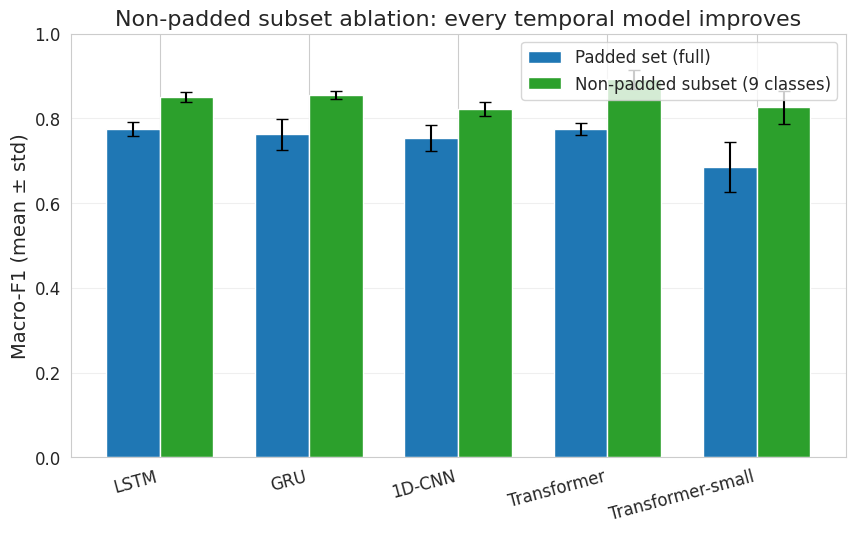

In [ ]:
# non-padded chart (padded set vs non-padded subset)
mods = ['LSTM', 'GRU', '1D-CNN', 'Transformer', 'Transformer-small']
padded_means = [repeat_last_map[m] for m in mods]
padded_stds  = [repeat_last_std[m] for m in mods]
nopad_map  = {r['model'].replace('-NoPad', ''): r['f1_macro_mean'] for _, r in nopad_summary.iterrows()}
nopad_stdm = {r['model'].replace('-NoPad', ''): r['f1_macro_std' ] for _, r in nopad_summary.iterrows()}

xs = np.arange(len(mods))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(xs - width/2, padded_means, width, yerr=padded_stds, capsize=4,
       label='Padded set (full)',  color='#1f77b4')
ax.bar(xs + width/2, [nopad_map.get(m, np.nan) for m in mods], width,
       yerr=[nopad_stdm.get(m, 0.0) for m in mods],
       capsize=4, label=f'Non-padded subset ({n_nopad} classes)', color='#2ca02c')
ax.set_xticks(xs); ax.set_xticklabels(mods, rotation=15, ha='right')
ax.set_ylabel('Macro-F1 (mean ± std)')
ax.set_title('Non-padded subset ablation: every temporal model improves')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_nopad_ablation_v4')
plt.show()
free_memory()


---
## T-sweep × LR-sweep — multi-seed

Heavy. Runs `T ∈ {5, 10, 20}` × LR ∈ {1e-3, 5e-4} for LSTM/GRU/1D-CNN, and
× {1e-3, 5e-4, 1e-4} for the Transformer, for every seed in `SEEDS_TSWEEP`
(defaults to `SEEDS`). `tsweep_per_seed.csv` is checkpointed after every
single (model, seed, T, LR) training run, so a disconnect costs at most one
run. If runtime is tight, set `SEEDS_TSWEEP = [42]` in the configuration cell.


In [ ]:
# T-sweep helper + run (checkpointed after every training run)
def _tsweep_split(seed):
    (Xtr, ytr, _), (Xte, yte, _), _ = _split_and_scale(seed)
    mm, side, n_pad = fit_image_enc(Xtr)
    Xtr_img = encode_imgs(mm, Xtr, side, n_pad)
    Xte_img = encode_imgs(mm, Xte, side, n_pad)
    return Xtr, ytr, Xte, yte, Xtr_img, Xte_img, side

T_SWEEP_ROWS = []

def _checkpoint_tsweep():
    pd.DataFrame(T_SWEEP_ROWS).to_csv(os.path.join(FIG_DIR, 'tsweep_per_seed.csv'), index=False)

def _run_tsweep_recurrent(builder, name):
    for seed in SEEDS_TSWEEP:
        set_global_seed(seed)
        Xtr, ytr, Xte, yte, _, _, _ = _tsweep_split(seed)
        cw = class_weight_dict(ytr, NUM_CLASSES)
        for T in T_SWEEP:
            Xtr_t = Xtr[:, -T:, :]
            Xte_t = Xte[:, -T:, :]
            for lr in LR_SWEEP_REC:
                es, rl = make_callbacks()
                m = builder(T, F, NUM_CLASSES, lr=lr)
                t0 = time.time()
                m.fit(Xtr_t, ytr, validation_split=0.15, epochs=EPOCHS,
                      batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
                t = time.time() - t0
                yp = np.argmax(m.predict(Xte_t, verbose=0), axis=1)
                f1 = round(f1_score(yte, yp, average='macro', zero_division=0), 4)
                T_SWEEP_ROWS.append({'model': name, 'seed': seed, 'T': T, 'LR': lr,
                                     'f1_macro': f1, 'time_s': round(t, 1)})
                _checkpoint_tsweep()
                print(f'  [{name}] seed={seed} T={T} lr={lr}: F1={f1} ({t:.1f}s)')
                del m; free_memory()

def _run_tsweep_transformer():
    for seed in SEEDS_TSWEEP:
        set_global_seed(seed)
        _, ytr, _, yte, Xtr_img, Xte_img, side = _tsweep_split(seed)
        cw = class_weight_dict(ytr, NUM_CLASSES)
        for T in T_SWEEP:
            Xtr_t = Xtr_img[:, -T:]
            Xte_t = Xte_img[:, -T:]
            for lr in LR_SWEEP_TRANS:
                es, rl = make_callbacks()
                m = build_transformer(T, side, NUM_CLASSES, lr=lr)
                t0 = time.time()
                m.fit(Xtr_t, ytr, validation_split=0.15, epochs=EPOCHS,
                      batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
                t = time.time() - t0
                yp = np.argmax(m.predict(Xte_t, verbose=0), axis=1)
                f1 = round(f1_score(yte, yp, average='macro', zero_division=0), 4)
                T_SWEEP_ROWS.append({'model': 'Transformer', 'seed': seed, 'T': T, 'LR': lr,
                                     'f1_macro': f1, 'time_s': round(t, 1)})
                _checkpoint_tsweep()
                print(f'  [Transformer] seed={seed} T={T} lr={lr}: F1={f1} ({t:.1f}s)')
                del m; free_memory()

print(f'T-sweep across SEEDS_TSWEEP={SEEDS_TSWEEP}')
_run_tsweep_recurrent(build_lstm,  'LSTM')
_run_tsweep_recurrent(build_gru,   'GRU')
_run_tsweep_recurrent(build_cnn1d, '1D-CNN')
_run_tsweep_transformer()

tsweep_df = pd.DataFrame(T_SWEEP_ROWS)
_checkpoint_tsweep()
print(f'T-sweep complete: {len(tsweep_df)} runs')


T-sweep across SEEDS_TSWEEP=[2, 42, 123]
  [LSTM] seed=2 T=5 lr=0.001: F1=0.6607 (74.8s)
  [LSTM] seed=2 T=5 lr=0.0005: F1=0.6447 (78.0s)
  [LSTM] seed=2 T=10 lr=0.001: F1=0.7523 (126.8s)
  [LSTM] seed=2 T=10 lr=0.0005: F1=0.7251 (130.9s)
  [LSTM] seed=2 T=20 lr=0.001: F1=0.798 (139.0s)
  [LSTM] seed=2 T=20 lr=0.0005: F1=0.7896 (137.2s)
  [LSTM] seed=42 T=5 lr=0.001: F1=0.6759 (104.1s)
  [LSTM] seed=42 T=5 lr=0.0005: F1=0.6261 (103.6s)
  [LSTM] seed=42 T=10 lr=0.001: F1=0.7399 (91.6s)
  [LSTM] seed=42 T=10 lr=0.0005: F1=0.7194 (115.0s)
  [LSTM] seed=42 T=20 lr=0.001: F1=0.7718 (110.6s)
  [LSTM] seed=42 T=20 lr=0.0005: F1=0.7649 (134.3s)
  [LSTM] seed=123 T=5 lr=0.001: F1=0.6539 (78.2s)
  [LSTM] seed=123 T=5 lr=0.0005: F1=0.6333 (86.1s)
  [LSTM] seed=123 T=10 lr=0.001: F1=0.7278 (117.8s)
  [LSTM] seed=123 T=10 lr=0.0005: F1=0.7124 (105.5s)
  [LSTM] seed=123 T=20 lr=0.001: F1=0.7625 (110.9s)
  [LSTM] seed=123 T=20 lr=0.0005: F1=0.7787 (149.6s)
  [GRU] seed=2 T=5 lr=0.001: F1=0.6733 (95.8

In [23]:
# T-sweep summary: ONE best learning rate per (model, T) — the LR with the
# best MEAN macro-F1 across seeds — then mean ± std across seeds at that LR.
# (Selecting the best LR separately per seed is optimistically biased.)
lr_stats = (tsweep_df.groupby(['model', 'T', 'LR'])['f1_macro']
            .agg(['mean', 'std', 'count']).reset_index())
best_idx = lr_stats.groupby(['model', 'T'])['mean'].idxmax()
agg = (lr_stats.loc[best_idx]
       .rename(columns={'mean': 'f1_macro_mean', 'std': 'f1_macro_std', 'count': 'n_seeds'})
       .sort_values(['model', 'T']).reset_index(drop=True))
agg['f1_macro_std'] = agg['f1_macro_std'].fillna(0.0)
agg.to_csv(os.path.join(FIG_DIR, 'tsweep_summary.csv'), index=False)
print(agg.to_string(index=False))

# transparency: the optimistic per-seed-best-LR view (NOT used in the paper)
best_per_seed = tsweep_df.loc[tsweep_df.groupby(['model', 'seed', 'T'])['f1_macro'].idxmax()]
best_per_seed.to_csv(os.path.join(FIG_DIR, 'tsweep_best_lr_per_seed.csv'), index=False)


      model  T     LR  f1_macro_mean  f1_macro_std  n_seeds
     1D-CNN  5 0.0005       0.660533      0.015963        3
     1D-CNN 10 0.0010       0.737633      0.012191        3
     1D-CNN 20 0.0005       0.729500      0.043194        3
        GRU  5 0.0010       0.650533      0.020538        3
        GRU 10 0.0010       0.719933      0.021373        3
        GRU 20 0.0005       0.765900      0.032284        3
       LSTM  5 0.0010       0.663500      0.011264        3
       LSTM 10 0.0010       0.740000      0.012250        3
       LSTM 20 0.0005       0.777733      0.012378        3
Transformer  5 0.0005       0.571433      0.076295        3
Transformer 10 0.0005       0.674467      0.022234        3
Transformer 20 0.0010       0.744533      0.032173        3


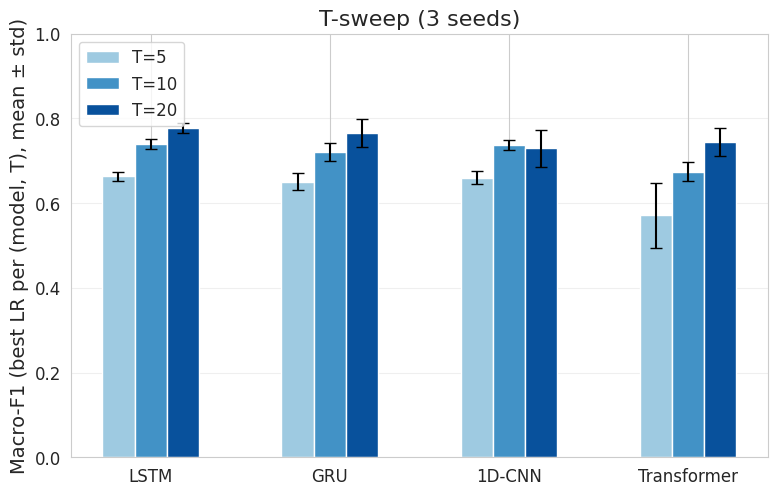

In [24]:
# T-sweep figure: bar grid (model × T) with std error bars
fig, ax = plt.subplots(figsize=(9, 5.5))
order_models = ['LSTM', 'GRU', '1D-CNN', 'Transformer']
order_T      = list(T_SWEEP)
n_T = len(order_T)
width = 0.18
xs = np.arange(len(order_models))
T_colors = {5: '#9ecae1', 10: '#4292c6', 20: '#08519c'}

for i, T in enumerate(order_T):
    means = []
    stds  = []
    for mod in order_models:
        sub = agg[(agg['model'] == mod) & (agg['T'] == T)]
        if len(sub) == 0:
            means.append(0); stds.append(0)
        else:
            means.append(float(sub['f1_macro_mean'].iloc[0]))
            stds.append (float(sub['f1_macro_std' ].iloc[0]))
    offset = (i - (n_T - 1) / 2) * width
    bars = ax.bar(xs + offset, means, width, yerr=stds, capsize=4,
                  color=T_colors[T], label=f'T={T}')
ax.set_xticks(xs); ax.set_xticklabels(order_models)
ax.set_ylabel('Macro-F1 (best LR per (model, T), mean ± std)')
ax.set_title(f'T-sweep ({len(SEEDS_TSWEEP)} seeds)')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper left')
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_tsweep_v4')
plt.show()

---
## Realistic eval — time-based split (degenerate)

Sort flows by timestamp, take chronological 80/20. CIC-IDS2017's day-by-day attack scheduling makes this degenerate (only 2 of 13 classes survive in the test set). Reported for completeness.

In [25]:
# time split prep (deterministic — split is on timestamp, not seed)
def _time_split_prep():
    df_sorted = df.sort_values(TIME_COL).reset_index(drop=True)
    cut = int(TRAIN_RATIO * len(df_sorted))
    df_tr = df_sorted.iloc[:cut].reset_index(drop=True)
    df_te = df_sorted.iloc[cut:].reset_index(drop=True)
    Xtr, ytr, Mtr, _ = build_windows_inline(df_tr, repeat_last=False)
    Xte, yte, Mte, _ = build_windows_inline(df_te, repeat_last=False)
    present = sorted(set(np.unique(ytr)) & set(np.unique(yte)))
    rmap = {old: new for new, old in enumerate(present)}
    keep_tr = np.isin(ytr, present); keep_te = np.isin(yte, present)
    Xtr, ytr, Mtr = Xtr[keep_tr], np.array([rmap[v] for v in ytr[keep_tr]]), Mtr[keep_tr]
    Xte, yte, Mte = Xte[keep_te], np.array([rmap[v] for v in yte[keep_te]]), Mte[keep_te]
    return (Xtr, ytr, Mtr), (Xte, yte, Mte), present

print('Building time-split windows (one-time)...')
TIME_TR, TIME_TE, TIME_PRESENT = _time_split_prep()
print(f'time split: train {TIME_TR[0].shape} / test {TIME_TE[0].shape}, '
      f'classes={len(TIME_PRESENT)}')
assert len(TIME_PRESENT) >= 2, (
    f'degenerate time split: only {len(TIME_PRESENT)} class(es) survive in train/test — aborting early')

Building time-split windows (one-time)...
time split: train (504660, 20, 76) / test (52539, 20, 76), classes=2


In [26]:
# train block factory (used by both time and group splits)
#
# PROTOCOL NOTE: the leakage-free splits use zero-pad + mask windows (the
# cleaner scheme: repeat-last padding would let models exploit the repeated
# final flow). The matched same-padding baseline for the temporal models is
# the padding_zp experiment above. The static models read the LAST REAL FLOW
# of each window, so their inputs are identical under either padding scheme
# and remain directly comparable to the random split.
def _make_realistic_trainers(TR, TE, PRESENT, name_suffix):
    """Returns ({label: train_fn(seed)}, n_class, class_names) for all 9 models.

    PRESENT carries 15-class label indices (build_windows_inline returns the
    original label encoding), so class names index into CLASS_NAMES_15.
    """
    n_class = len(PRESENT)
    class_names_local = [CLASS_NAMES_15[i] for i in PRESENT]
    Xtr, ytr, Mtr = TR
    Xte, yte, Mte = TE

    # pre-scale once per call (data does not change per seed; only model init does)
    sc = fit_zscore(Xtr, mask=Mtr)
    Xtr_s = apply_zscore(sc, Xtr, mask=Mtr)
    Xte_s = apply_zscore(sc, Xte, mask=Mte)
    mm, side, n_pad = fit_image_enc(Xtr_s, mask=Mtr)
    Xtr_img = encode_imgs(mm, Xtr_s, side, n_pad, mask=Mtr)
    Xte_img = encode_imgs(mm, Xte_s, side, n_pad, mask=Mte)

    # static models consume the LAST REAL flow of each window. Under
    # zero-padding, slot -1 is an all-zeros row for padded windows, so we
    # index the last real position via the mask instead.
    last_tr = Mtr.sum(axis=1).astype(int) - 1
    last_te = Mte.sum(axis=1).astype(int) - 1
    Xtr_l = Xtr_s[np.arange(len(Xtr_s)), last_tr, :]
    Xte_l = Xte_s[np.arange(len(Xte_s)), last_te, :]
    Xtr_img_l = Xtr_img[np.arange(len(Xtr_img)), last_tr]
    Xte_img_l = Xte_img[np.arange(len(Xte_img)), last_te]

    cw = class_weight_dict(ytr, n_class)

    def t_svm(seed):
        idx = cap_per_class(ytr, SVM_CAP, seed)
        m = build_svm(seed)
        t0 = time.time(); m.fit(Xtr_l[idx], ytr[idx]); t = time.time() - t0
        return yte, m.predict(Xte_l), None, t
    def t_rf(seed):
        idx = cap_per_class(ytr, RF_CAP, seed)
        m = build_rf(seed)
        t0 = time.time(); m.fit(Xtr_l[idx], ytr[idx]); t = time.time() - t0
        yp = m.predict(Xte_l); pr = m.predict_proba(Xte_l)
        return yte, yp, pr, t
    def t_mlp(seed):
        es, rl = make_callbacks()
        m = build_mlp(F, n_class)
        t0 = time.time()
        m.fit(Xtr_l, ytr, validation_split=0.15, epochs=EPOCHS,
              batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
        t = time.time() - t0
        pr = m.predict(Xte_l, verbose=0)
        return yte, np.argmax(pr, axis=1), pr, t
    def t_imgcnn(seed):
        es, rl = make_callbacks()
        m = build_image_cnn(side, n_class)
        t0 = time.time()
        m.fit(Xtr_img_l, ytr, validation_split=0.15, epochs=EPOCHS,
              batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
        t = time.time() - t0
        pr = m.predict(Xte_img_l, verbose=0)
        return yte, np.argmax(pr, axis=1), pr, t
    def _seq(builder, lr, mask=True):
        def _fn(seed):
            es, rl = make_callbacks()
            m = builder(TIMESTEPS, F, n_class, lr=lr, mask=mask)
            t0 = time.time()
            m.fit(Xtr_s, ytr, validation_split=0.15, epochs=EPOCHS,
                  batch_size=BATCH_SEQ, class_weight=cw, callbacks=[es, rl], verbose=0)
            t = time.time() - t0
            pr = m.predict(Xte_s, verbose=0)
            return yte, np.argmax(pr, axis=1), pr, t
        return _fn
    def _trans(builder):
        def _fn(seed):
            es, rl = make_callbacks()
            m = builder(TIMESTEPS, side, n_class)
            t0 = time.time()
            m.fit([Xtr_img, Mtr], ytr, validation_split=0.15, epochs=EPOCHS,
                  batch_size=BATCH_TRANS, class_weight=cw, callbacks=[es, rl], verbose=0)
            t = time.time() - t0
            pr = m.predict([Xte_img, Mte], verbose=0)
            return yte, np.argmax(pr, axis=1), pr, t
        return _fn

    return {
        f'SVM ({name_suffix})':                t_svm,
        f'RF ({name_suffix})':                 t_rf,
        f'MLP ({name_suffix})':                t_mlp,
        f'Image-CNN ({name_suffix})':          t_imgcnn,
        f'LSTM ({name_suffix})':               _seq(build_lstm,   LR_LSTM),
        f'GRU ({name_suffix})':                _seq(build_gru,    LR_GRU),
        # Conv1D cannot consume a Keras mask, so the 1D-CNN sees the zeroed
        # inputs themselves (mask=False avoids a silently-discarded Masking layer)
        f'1D-CNN ({name_suffix})':             _seq(build_cnn1d,  LR_CNN1D, mask=False),
        f'Transformer ({name_suffix})':        _trans(build_masked_transformer),
        f'Transformer-small ({name_suffix})':  _trans(build_masked_transformer_small),
    }, n_class, class_names_local


In [27]:
# run time split
ALL_AGG_TIME = []
ALL_PS_TIME  = []
ALL_PC_TIME  = []
trainers_time, n_class_time, names_time = _make_realistic_trainers(TIME_TR, TIME_TE, TIME_PRESENT, 'time')
for label, fn in trainers_time.items():
    ps, pc, ag = run_seeds('time_split', label, fn, SEEDS, n_class_time, names_time)
    ALL_AGG_TIME.append(ag); ALL_PS_TIME += ps; ALL_PC_TIME += pc

time_summary = pd.DataFrame(ALL_AGG_TIME).sort_values('f1_macro_mean', ascending=False)
time_summary.to_csv(os.path.join(FIG_DIR, 'time_split_summary.csv'), index=False)
pd.DataFrame(ALL_PS_TIME).to_csv(os.path.join(FIG_DIR, 'time_split_per_seed.csv'),           index=False)
pd.DataFrame(ALL_PC_TIME).to_csv(os.path.join(FIG_DIR, 'time_split_per_class_per_seed.csv'), index=False)
print(time_summary.to_string(index=False))
free_memory()


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (time)] seed=2: F1m=0.4799 acc=0.9228 rec_m=0.4614  (51.5s train)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (time)] seed=42: F1m=0.4796 acc=0.9217 rec_m=0.4609  (51.2s train)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (time)] seed=123: F1m=0.4807 acc=0.9258 rec_m=0.4629  (47.1s train)
  [RF (time)] seed=2: F1m=0.5 acc=0.9998 rec_m=0.4999  (0.6s train)
  [RF (time)] seed=42: F1m=0.5 acc=0.9998 rec_m=0.4999  (0.6s train)
  [RF (time)] seed=123: F1m=0.5 acc=0.9999 rec_m=0.5  (0.6s train)
  [MLP (time)] seed=2: F1m=0.5 acc=1.0 rec_m=0.5  (51.4s train)
  [MLP (time)] seed=42: F1m=0.5 acc=1.0 rec_m=0.5  (15.6s train)
  [MLP (time)] seed=123: F1m=0.5 acc=1.0 rec_m=0.5  (15.3s train)
  [Image-CNN (time)] seed=2: F1m=0.5 acc=1.0 rec_m=0.5  (22.1s train)
  [Image-CNN (time)] seed=42: F1m=0.5 acc=1.0 rec_m=0.5  (23.4s train)
  [Image-CNN (time)] seed=123: F1m=0.5 acc=1.0 rec_m=0.5  (25.8s train)
  [LSTM (time)] seed=2: F1m=0.5666 acc=0.9998 rec_m=0.9999  (117.1s train)
  [LSTM (time)] seed=42: F1m=0.5 acc=0.9999 rec_m=0.5  (87.4s train)
  [LSTM (time)] seed=123: F1m=0.5 acc=0.9999 rec_m=0.5  (50.7s train)
  [GRU (time)] seed=2: F1m=0.5499 acc=0.9997 rec_m=0.9998  (85.7s train)
  [GRU (time)] seed=42: F1

---
## Realistic eval — group-by-5-tuple split

Partition 5-tuples 80/20 *before* windowing, so no conversation appears in both train and test. Windows are zero-padded + masked (see the protocol note in the trainer-factory cell); static models read the last real flow. 3 seeds. Per-class recall heatmaps saved as PDF.

In [28]:
# group split prep: partition by (string-key) 5-tuple per seed.
# build_windows_inline returns 15-class label indices, so class names below
# index into CLASS_NAMES_15.

def _group_split_prep(seed):
    df_loc = df.copy()
    df_loc['_tup_key'] = df_loc[TUPLE_COLS].astype(str).agg('|'.join, axis=1)
    keys = df_loc['_tup_key'].unique()
    rng = np.random.RandomState(seed)
    shuffled = rng.permutation(keys)
    n_train = int(TRAIN_RATIO * len(shuffled))
    train_keys = set(shuffled[:n_train])
    df_tr = df_loc[df_loc['_tup_key'].isin(train_keys)].drop(columns=['_tup_key'])
    df_te = df_loc[~df_loc['_tup_key'].isin(train_keys)].drop(columns=['_tup_key'])
    Xtr, ytr, Mtr, _ = build_windows_inline(df_tr, repeat_last=False)
    Xte, yte, Mte, _ = build_windows_inline(df_te, repeat_last=False)
    present = sorted(set(np.unique(ytr)) & set(np.unique(yte)))
    rmap = {old: new for new, old in enumerate(present)}
    keep_tr = np.isin(ytr, present); keep_te = np.isin(yte, present)
    Xtr, ytr, Mtr = Xtr[keep_tr], np.array([rmap[v] for v in ytr[keep_tr]]), Mtr[keep_tr]
    Xte, yte, Mte = Xte[keep_te], np.array([rmap[v] for v in yte[keep_te]]), Mte[keep_te]
    return (Xtr, ytr, Mtr), (Xte, yte, Mte), present

# Re-use existing partitions if already built; otherwise build now.
if 'SEED_PARTITIONS' not in globals() or not SEED_PARTITIONS:
    SEED_PARTITIONS = {}
    for seed in SEEDS:
        print(f'Building group-split partition for seed={seed} ...')
        SEED_PARTITIONS[seed] = _group_split_prep(seed)
        Xtr_s, ytr_s, _ = SEED_PARTITIONS[seed][0]
        Xte_s, yte_s, _ = SEED_PARTITIONS[seed][1]
        pres_s          = SEED_PARTITIONS[seed][2]
        print(f'  seed={seed}: train {Xtr_s.shape} / test {Xte_s.shape}, classes={len(pres_s)}')
else:
    print(f'SEED_PARTITIONS already built for seeds {list(SEED_PARTITIONS.keys())} — reusing.')
    for seed in SEEDS:
        Xtr_s, _, _ = SEED_PARTITIONS[seed][0]
        Xte_s, _, _ = SEED_PARTITIONS[seed][1]
        pres_s      = SEED_PARTITIONS[seed][2]
        print(f'  seed={seed}: train {Xtr_s.shape} / test {Xte_s.shape}, classes={len(pres_s)}')

# Reference partition (for class_names alignment in CSVs)
REF_TR, REF_TE, REF_PRESENT = SEED_PARTITIONS[SEEDS[0]]
n_class_group = len(REF_PRESENT)
names_group   = [CLASS_NAMES_15[i] for i in REF_PRESENT]
print(f'\nReference (seed={SEEDS[0]}): {n_class_group} classes')
print(f'names_group: {names_group}')
for seed in SEEDS:
    n_s = len(SEED_PARTITIONS[seed][2])
    assert n_s >= 2, f'degenerate group split for seed {seed}: only {n_s} class(es) survive'


Building group-split partition for seed=2 ...
  seed=2: train (504926, 20, 76) / test (125333, 20, 76), classes=12
Building group-split partition for seed=42 ...
  seed=42: train (504037, 20, 76) / test (126227, 20, 76), classes=13
Building group-split partition for seed=123 ...
  seed=123: train (502986, 20, 76) / test (127278, 20, 76), classes=13

Reference (seed=2): 12 classes
names_group: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack – Brute Force', 'Web Attack – Sql Injection', 'Web Attack – XSS']


In [29]:
# run group split — per-seed partition + per-seed init for true variance estimate
# Checkpoints all three CSVs after every model, so a disconnect costs at most
# one model's training rather than the whole block.
ALL_PS_GROUP  = []
ALL_PC_GROUP  = []
ALL_RECALL_GROUP_PER_SEED = []
per_model_results = {}

# union of class names across seed partitions (rare classes can be absent
# from one seed's split; their columns are padded with NaN so the per-class
# DataFrames stay rectangular)
all_seed_class_names = set()
for seed in SEEDS:
    for ci in SEED_PARTITIONS[seed][2]:
        all_seed_class_names.add(CLASS_NAMES_15[ci])
ALL_GROUP_CLASS_NAMES = [c for c in CLASS_NAMES_15 if c in all_seed_class_names]
print(f'Per-class CSV columns ({len(ALL_GROUP_CLASS_NAMES)}): {ALL_GROUP_CLASS_NAMES}')

def _padded_per_class(metric_fn, y_true, y_pred, present_local_names):
    """Per-class metric padded to the union of class names seen across seeds."""
    raw = metric_fn(y_true, y_pred, present_local_names)
    out = {n: float('nan') for n in ALL_GROUP_CLASS_NAMES}
    out.update(raw)
    return out

for seed in SEEDS:
    set_global_seed(seed)
    TR, TE, PRESENT = SEED_PARTITIONS[seed]
    n_class_s = len(PRESENT)
    names_s   = [CLASS_NAMES_15[i] for i in PRESENT]
    trainers_s, _, _ = _make_realistic_trainers(TR, TE, PRESENT, 'group')
    for label, fn in trainers_s.items():
        per_model_results.setdefault(label, [])
        set_global_seed(seed)
        t0 = time.time()
        y_true, y_pred, y_proba, t_train = fn(seed)
        bi = names_s.index('BENIGN') if 'BENIGN' in names_s else 0
        m = metrics_dict(y_true, y_pred, n_class_s, y_proba=y_proba,
                         train_seconds=t_train, benign_index=bi)
        m.update({'experiment': 'group_split', 'model': label, 'seed': seed,
                  'wall_seconds': round(time.time() - t0, 2)})
        ALL_PS_GROUP.append(m)
        per_model_results[label].append(m)
        row_f1 = {'experiment': 'group_split', 'model': label, 'seed': seed}
        row_f1.update(_padded_per_class(per_class_f1_dict, y_true, y_pred, names_s))
        ALL_PC_GROUP.append(row_f1)
        row_rc = {'experiment': 'group_split', 'model': label, 'seed': seed}
        row_rc.update(_padded_per_class(per_class_recall_dict, y_true, y_pred, names_s))
        ALL_RECALL_GROUP_PER_SEED.append(row_rc)
        print(f'  [{label}] seed={seed}: F1m={m["f1_macro"]} acc={m["accuracy"]} '
              f'rec_m={m["recall_macro"]}  ({t_train:.1f}s train)')
        # CHECKPOINT to Drive after each model
        pd.DataFrame(ALL_PS_GROUP).to_csv(os.path.join(FIG_DIR, 'group_split_per_seed.csv'), index=False)
        pd.DataFrame(ALL_PC_GROUP).to_csv(os.path.join(FIG_DIR, 'group_split_per_class_per_seed.csv'), index=False)
        pd.DataFrame(ALL_RECALL_GROUP_PER_SEED).to_csv(
            os.path.join(FIG_DIR, 'group_split_per_class_recall_per_seed.csv'), index=False)
        free_memory()

ALL_AGG_GROUP = [aggregate_seeds(rows) for rows in per_model_results.values()]
group_summary = pd.DataFrame(ALL_AGG_GROUP).sort_values('f1_macro_mean', ascending=False)
group_summary.to_csv(os.path.join(FIG_DIR, 'group_split_summary.csv'), index=False)
print(group_summary.to_string(index=False))
free_memory()


Per-class CSV columns (13): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS slowloris', 'FTP-Patator', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack – Brute Force', 'Web Attack – Sql Injection', 'Web Attack – XSS']


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (group)] seed=2: F1m=0.4239 acc=0.8539 rec_m=0.7057  (753.5s train)
  [RF (group)] seed=2: F1m=0.8197 acc=0.998 rec_m=0.8227  (3.7s train)
  [MLP (group)] seed=2: F1m=0.5223 acc=0.9285 rec_m=0.7754  (47.0s train)
  [Image-CNN (group)] seed=2: F1m=0.4085 acc=0.8291 rec_m=0.7268  (36.6s train)
  [LSTM (group)] seed=2: F1m=0.7758 acc=0.9951 rec_m=0.8554  (57.3s train)
  [GRU (group)] seed=2: F1m=0.7967 acc=0.9967 rec_m=0.8609  (123.8s train)
  [1D-CNN (group)] seed=2: F1m=0.7259 acc=0.9963 rec_m=0.7749  (49.9s train)
  [Transformer (group)] seed=2: F1m=0.6131 acc=0.9829 rec_m=0.7336  (228.7s train)
  [Transformer-small (group)] seed=2: F1m=0.3845 acc=0.9564 rec_m=0.5843  (243.3s train)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (group)] seed=42: F1m=0.3821 acc=0.8525 rec_m=0.7667  (734.4s train)
  [RF (group)] seed=42: F1m=0.7415 acc=0.9981 rec_m=0.7566  (3.8s train)
  [MLP (group)] seed=42: F1m=0.5189 acc=0.9329 rec_m=0.7988  (53.7s train)
  [Image-CNN (group)] seed=42: F1m=0.4174 acc=0.8984 rec_m=0.7216  (48.7s train)
  [LSTM (group)] seed=42: F1m=0.7172 acc=0.9975 rec_m=0.8317  (132.0s train)
  [GRU (group)] seed=42: F1m=0.7007 acc=0.9954 rec_m=0.8471  (136.8s train)
  [1D-CNN (group)] seed=42: F1m=0.7273 acc=0.9979 rec_m=0.8104  (85.3s train)
  [Transformer (group)] seed=42: F1m=0.5846 acc=0.972 rec_m=0.6833  (245.1s train)
  [Transformer-small (group)] seed=42: F1m=0.3478 acc=0.9526 rec_m=0.5232  (243.1s train)


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


  [SVM (group)] seed=123: F1m=0.3813 acc=0.8755 rec_m=0.6439  (647.3s train)
  [RF (group)] seed=123: F1m=0.7737 acc=0.9977 rec_m=0.7752  (3.7s train)
  [MLP (group)] seed=123: F1m=0.5308 acc=0.9453 rec_m=0.7056  (49.8s train)
  [Image-CNN (group)] seed=123: F1m=0.3896 acc=0.8763 rec_m=0.6732  (52.7s train)
  [LSTM (group)] seed=123: F1m=0.7645 acc=0.9967 rec_m=0.8054  (103.6s train)
  [GRU (group)] seed=123: F1m=0.7098 acc=0.991 rec_m=0.8169  (91.9s train)
  [1D-CNN (group)] seed=123: F1m=0.7465 acc=0.9964 rec_m=0.7909  (51.6s train)
  [Transformer (group)] seed=123: F1m=0.4496 acc=0.9601 rec_m=0.5814  (237.9s train)
  [Transformer-small (group)] seed=123: F1m=0.4144 acc=0.9051 rec_m=0.689  (240.9s train)
 experiment                     model  n_seeds  accuracy_mean  accuracy_std  f1_macro_mean  f1_macro_std  f1_weighted_mean  f1_weighted_std  recall_macro_mean  recall_macro_std  precision_macro_mean  precision_macro_std  fpr_mean  fpr_std  fnr_mean  fnr_std  roc_auc_mean  roc_auc_std

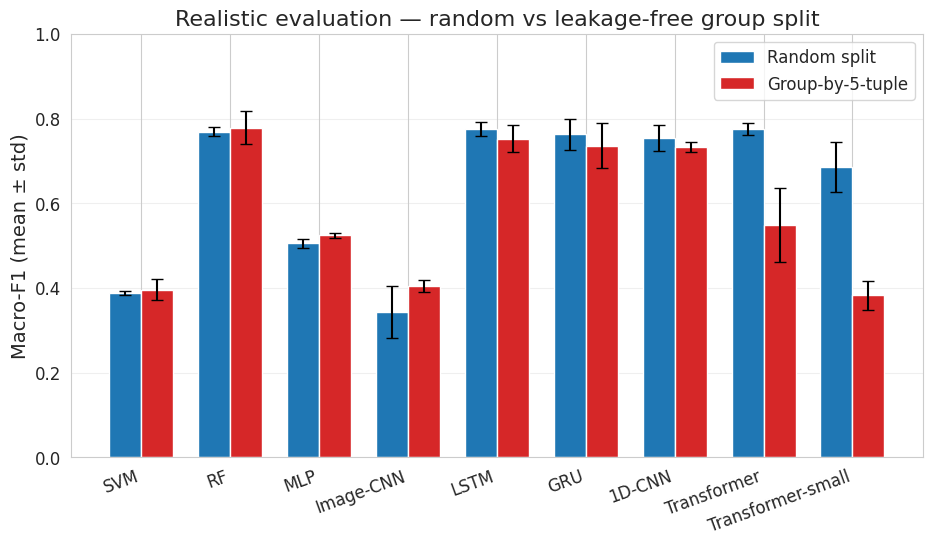

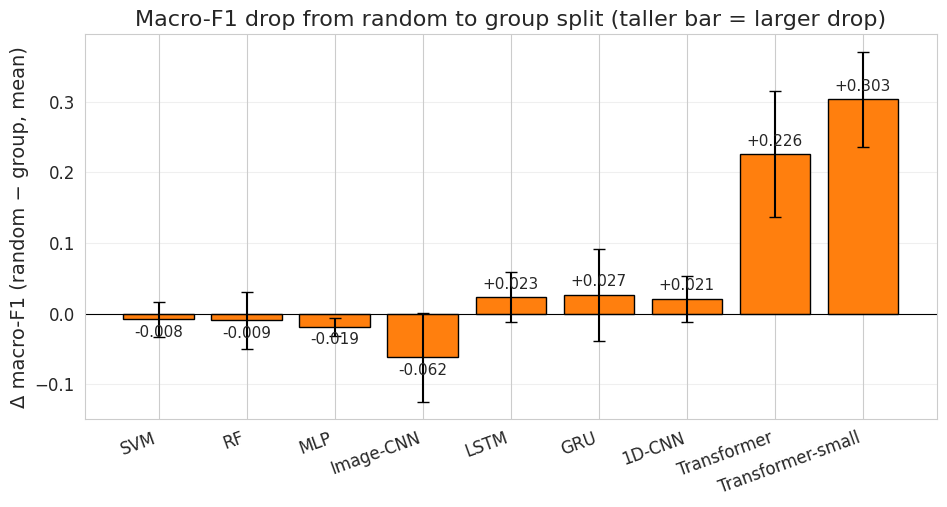

In [30]:
# Realistic-eval bar chart: random vs group, mean ± std (PDF)

def _strip(s): return s.replace(' (group)', '').replace(' (time)', '')
group_clean = group_summary.copy()
group_clean['model'] = group_clean['model'].apply(_strip)

mods_order = ['SVM', 'RF', 'MLP', 'Image-CNN', 'LSTM', 'GRU', '1D-CNN', 'Transformer', 'Transformer-small']
random_means = [random_summary_df.set_index('model')['f1_macro_mean'].get(m, np.nan) for m in mods_order]
random_stds  = [random_summary_df.set_index('model')['f1_macro_std' ].get(m, 0.0)    for m in mods_order]
group_means  = [group_clean.set_index('model')['f1_macro_mean'].get(m, np.nan) for m in mods_order]
group_stds   = [group_clean.set_index('model')['f1_macro_std' ].get(m, 0.0)    for m in mods_order]

xs = np.arange(len(mods_order)); width = 0.36
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(xs - width/2, random_means, width, yerr=random_stds, capsize=4, label='Random split', color='#1f77b4')
ax.bar(xs + width/2, group_means,  width, yerr=group_stds,  capsize=4, label='Group-by-5-tuple', color='#d62728')
ax.set_xticks(xs); ax.set_xticklabels(mods_order, rotation=20, ha='right')
ax.set_ylabel('Macro-F1 (mean ± std)')
ax.set_title('Realistic evaluation — random vs leakage-free group split')
ax.set_ylim(0, 1.0)
ax.legend(loc='upper right')
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_realistic_eval_v4')
plt.show()

# Drops chart (random − group), with combined std error
drops = np.array(random_means) - np.array(group_means)
combined_std = np.sqrt(np.array(random_stds) ** 2 + np.array(group_stds) ** 2)
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(xs, drops, yerr=combined_std, capsize=4, color='#ff7f0e', edgecolor='black')
for x, d in zip(xs, drops):
    ax.text(x, d + (0.012 if d >= 0 else -0.025), f'{d:+.3f}', ha='center', fontsize=11)
ax.set_xticks(xs); ax.set_xticklabels(mods_order, rotation=20, ha='right')
ax.set_ylabel('Δ macro-F1 (random − group, mean)')
ax.set_title('Macro-F1 drop from random to group split (taller bar = larger drop)')
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, axis='y', alpha=0.3)
save_fig(fig, 'fig_realistic_drops_v4')
plt.show()


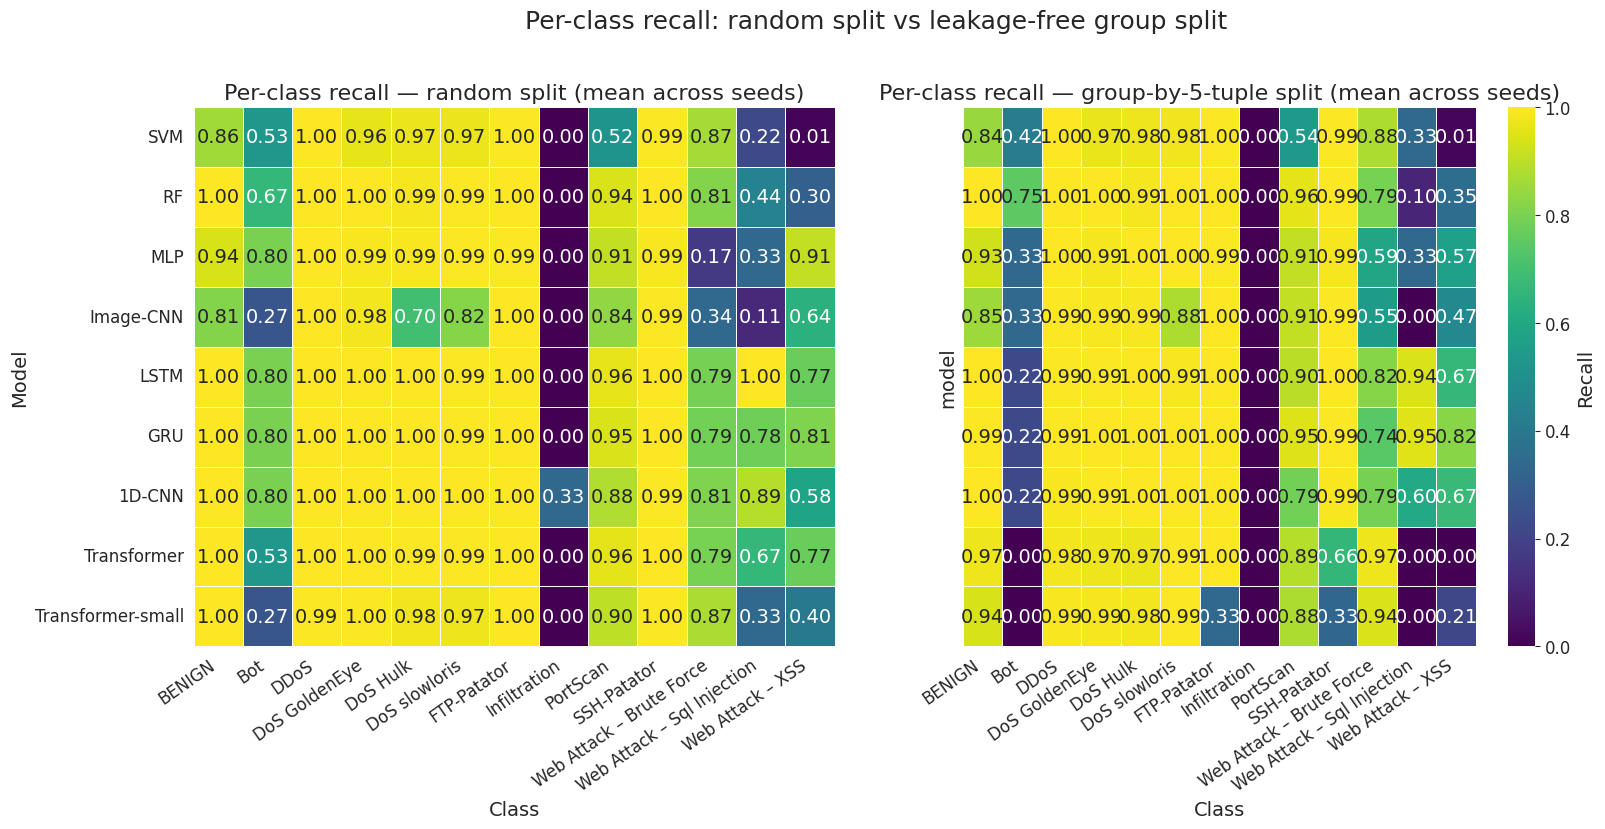

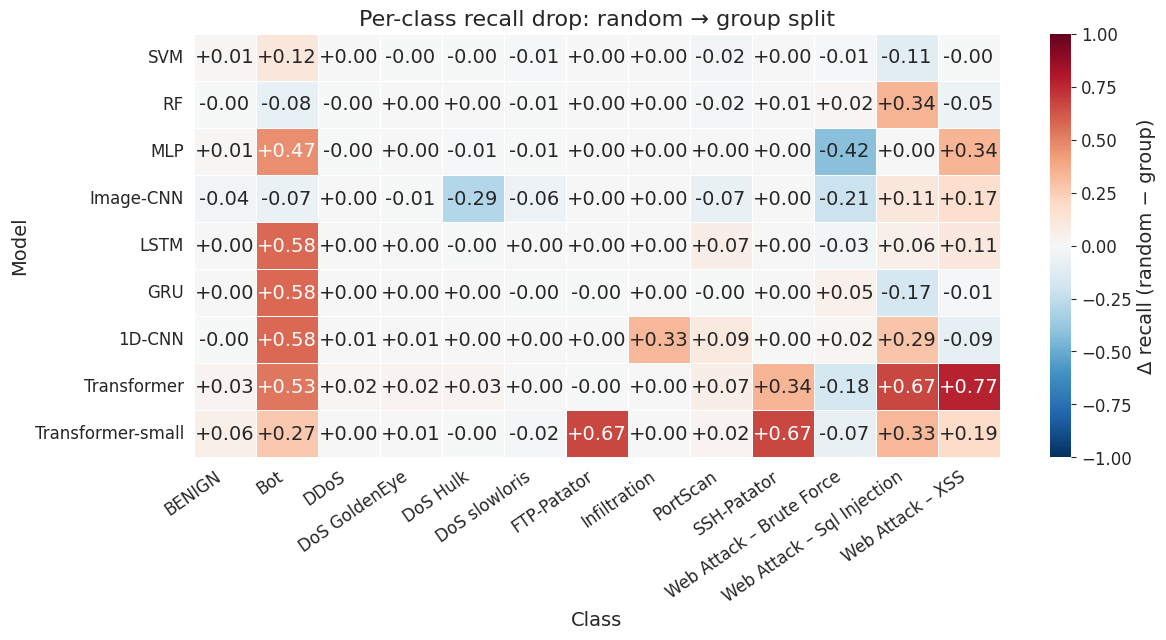

In [31]:
# Per-class recall heatmaps: random split vs group split (both: mean across seeds)
random_recall_mean = (pd.DataFrame(ALL_RECALL_RANDOM)
                      .drop(columns=['experiment', 'seed'])
                      .groupby('model').mean(numeric_only=True))
random_recall_mean = random_recall_mean.reindex([m for m in mods_order if m in random_recall_mean.index])

group_recall_df = pd.DataFrame(ALL_RECALL_GROUP_PER_SEED)
group_recall_df['model'] = group_recall_df['model'].apply(_strip)
group_recall_mean = (group_recall_df.drop(columns=['experiment', 'seed'])
                     .groupby('model').mean(numeric_only=True))
group_recall_mean = group_recall_mean.reindex([m for m in mods_order if m in group_recall_mean.index])
group_recall_mean.to_csv(os.path.join(FIG_DIR, 'group_per_class_recall_mean.csv'))

# column alignment using the union of both class sets, ordered by 15-class index
all_cols = sorted(
    set(random_recall_mean.columns) | set(group_recall_mean.columns),
    key=lambda c: CLASS_NAMES_15.index(c) if c in CLASS_NAMES_15 else 999,
)
random_recall_aligned = random_recall_mean.reindex(columns=all_cols)
group_recall_aligned  = group_recall_mean.reindex(columns=all_cols)

fig, axes = plt.subplots(1, 2, figsize=(max(18, 1.4 * len(all_cols)), 7), sharey=True)
sns.heatmap(random_recall_aligned, annot=True, fmt='.2f', cmap='viridis',
            ax=axes[0], cbar=False, vmin=0.0, vmax=1.0,
            linewidths=0.4, linecolor='white')
axes[0].set_title('Per-class recall — random split (mean across seeds)')
axes[0].set_xlabel('Class'); axes[0].set_ylabel('Model')
plt.setp(axes[0].get_xticklabels(), rotation=35, ha='right')

sns.heatmap(group_recall_aligned, annot=True, fmt='.2f', cmap='viridis',
            ax=axes[1], cbar=True, vmin=0.0, vmax=1.0,
            cbar_kws={'label': 'Recall'}, linewidths=0.4, linecolor='white')
axes[1].set_title('Per-class recall — group-by-5-tuple split (mean across seeds)')
axes[1].set_xlabel('Class')
plt.setp(axes[1].get_xticklabels(), rotation=35, ha='right')

fig.suptitle('Per-class recall: random split vs leakage-free group split', y=1.02)
save_fig(fig, 'fig_perclass_recall_by_split_v4')
plt.show()

# drop heatmap (random − group), only for columns present on BOTH sides
common_cols = [c for c in all_cols
               if c in random_recall_mean.columns and c in group_recall_mean.columns]
drop_recall = (random_recall_mean.reindex(columns=common_cols)
                                 .reindex(group_recall_aligned.index)
               - group_recall_mean.reindex(columns=common_cols))
fig, ax = plt.subplots(figsize=(max(10, 1.0 * len(common_cols)), 5.5))
sns.heatmap(drop_recall, annot=True, fmt='+.2f', cmap='RdBu_r',
            center=0, ax=ax, vmin=-1.0, vmax=1.0,
            linewidths=0.4, linecolor='white',
            cbar_kws={'label': 'Δ recall (random − group)'})
ax.set_title('Per-class recall drop: random → group split')
ax.set_xlabel('Class'); ax.set_ylabel('Model')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right')
save_fig(fig, 'fig_perclass_recall_drop_v4')
plt.show()
free_memory()


---
## Master summary CSV + figure index

All experiment summaries concatenated into one master file. List of every PDF/PNG written for the paper.

In [32]:
# master summary
master_rows = []
for src, df_in in [
    ('random',    random_summary_df),
    ('static15',  static15_summary),
    ('padding_zp', padding_summary),
    ('nopad',     nopad_summary),
    ('time_split',  time_summary),
    ('group_split', group_summary),
]:
    for _, r in df_in.iterrows():
        master_rows.append({**r.to_dict(), 'experiment': src})
master_df = pd.DataFrame(master_rows)
master_df.to_csv(os.path.join(FIG_DIR, 'master_summary_v4.csv'), index=False)
print(f'Master summary: {len(master_df)} rows → master_summary_v4.csv')

Master summary: 41 rows → master_summary_v4.csv


In [33]:
# figure index
figs = sorted([f for f in os.listdir(FIG_DIR) if f.endswith('.pdf')])
for f in figs:
    print(f'  {f}')

# Also list all CSVs
csvs = sorted([f for f in os.listdir(FIG_DIR) if f.endswith('.csv')])
for f in csvs:
    print(f'  {f}')

  fig_cm_lstm_v4.pdf
  fig_latency_bars_v4.pdf
  fig_latency_v4.pdf
  fig_nopad_ablation_v4.pdf
  fig_padding_ablation_v4.pdf
  fig_pareto_v4.pdf
  fig_per_class_f1_random_v4.pdf
  fig_perclass_recall_by_split_v4.pdf
  fig_perclass_recall_drop_v4.pdf
  fig_realistic_drops_v4.pdf
  fig_realistic_eval_v4.pdf
  fig_static15_v4.pdf
  fig_tsweep_v4.pdf
  group_per_class_recall_mean.csv
  group_split_per_class_per_seed.csv
  group_split_per_class_recall_per_seed.csv
  group_split_per_seed.csv
  group_split_summary.csv
  latency.csv
  master_summary_v4.csv
  nopad_per_seed.csv
  nopad_summary.csv
  padding_per_class_per_seed.csv
  padding_per_seed.csv
  padding_summary.csv
  params_table.csv
  pareto.csv
  per_seed_nopad_1D-CNN-NoPad.csv
  per_seed_nopad_GRU-NoPad.csv
  per_seed_nopad_LSTM-NoPad.csv
  per_seed_nopad_Transformer-NoPad.csv
  per_seed_nopad_Transformer-small-NoPad.csv
  per_seed_padding_zp_1D-CNN-ZP.csv
  per_seed_padding_zp_GRU-ZP.csv
  per_seed_padding_zp_LSTM-ZP.csv
  per_see

In [34]:
# final memory cleanup
free_memory()
print('Run complete. Outputs in:', FIG_DIR)

Run complete. Outputs in: /content/drive/MyDrive/EEE402_Project/figures_v5
